# Stochastic Optimization Scheduler Comparison

Single notebook orchestrating all experiment versions (V0–V5).

**Objective**: Compare learning rate schedulers (None, Exponential Decay, Cosine Annealing, Cyclic LR, One-Cycle) across optimizers (SGD, Adam) on convex (logistic regression) and non-convex (MLP on MNIST) problems.

**Metrics**: Convergence speed (EtT), Area Under Loss (AUL), empirical convergence rate (ρ̂), stability (RV/CV, SI), Robbins-Monro compliance.

## 1. Imports

In [24]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:
import time
from pathlib import Path
import pickle

import pandas as pd
import torch

from stoc_opt_scheduler_comparison.config import load_config
from stoc_opt_scheduler_comparison.data_load import get_dataloaders
from stoc_opt_scheduler_comparison.models import create_model
from stoc_opt_scheduler_comparison.training import get_optimizer, get_scheduler, train_loop, get_dynamic_scheduler_params
from stoc_opt_scheduler_comparison.tracking import MLflowLogger, load_results_from_mlflow
from stoc_opt_scheduler_comparison.training.lstar import (
    compute_convex_L_star,
    compute_empirical_L_star,
)
from stoc_opt_scheduler_comparison.evaluation import (
    TrainingHistory,
    compute_convergence_metrics,
    aggregate_metrics,
    compute_global_L_star,
    compute_global_initial_loss,
    compute_target_loss,
    epochs_to_target,
)
from stoc_opt_scheduler_comparison.visualization.plots import plot_all, plot_convergence_boxplot

print(f"PyTorch {torch.__version__} | Device CUDA: {torch.cuda.is_available()}")

PyTorch 2.11.0+cu130 | Device CUDA: True


## 2. Configuration

In [2]:
config = load_config("../configs/experiment_config.yaml")

print(f"Experiment: {config.experiment_name}")
print(f"Seeds: {config.seeds}")
print(f"Schedulers: {config.schedulers}")
print(f"Optimizers: {config.optimizers}")
print(f"Epochs: {config.epochs}, LR: {config.lr}, Batch: {config.batch_size}")
print(f"Experiments: {config.experiments}")

Experiment: scheduler_comparison_v5
Seeds: (6, 22, 84, 165, 405, 440, 492, 561, 910, 947)
Schedulers: ('none', 'cosine', 'exponential', 'cyclic', 'one-cycle')
Optimizers: ('sgd', 'adam')
Epochs: 100, LR: {'sgd': 0.01, 'adam': 0.001}, Batch: 128
Experiments: {'convex': ExperimentDef(model='logistic', dataset='breast_cancer', batch_size=128, epochs=100), 'non-convex': ExperimentDef(model='mlp', dataset='mnist', batch_size=128, epochs=100)}


In [3]:
# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Output directories
figures_dir = Path("../reports/figures")
figures_dir.mkdir(parents=True, exist_ok=True)
print(f"Figures saved to: {figures_dir.absolute()}")

results_dir = Path("../results")
results_dir.mkdir(parents=True, exist_ok=True)
print(f"Results saved to: {results_dir.absolute()}")

Using device: cuda
Figures saved to: /home/narto/Documents/uni_projects/MOS/stoc-opt_scheduler_comparison/notebooks/../reports/figures
Results saved to: /home/narto/Documents/uni_projects/MOS/stoc-opt_scheduler_comparison/notebooks/../results


## 3. Experiment Matrix

Each experiment is defined by: `(problem_type, scheduler, optimizer, seed)`.

The config specifies which model and dataset to use for each problem type.

In [4]:
def build_experiment_matrix(config):
    """Build list of (problem_type, scheduler, optimizer, seed) tuples."""
    matrix = []
    for problem_type, exp_def in config.experiments.items():
        for scheduler in config.schedulers:
            for optimizer in config.optimizers:
                for seed in config.seeds:
                    matrix.append((problem_type, exp_def, scheduler, optimizer, seed))
    return matrix

experiment_matrix = build_experiment_matrix(config)
print(f"Total experiments: {len(experiment_matrix)}")
print(f"  Convex: {len([e for e in experiment_matrix if e[0] == 'convex'])}")
print(f"  Non-convex: {len([e for e in experiment_matrix if e[0] == 'non-convex'])}")

Total experiments: 200
  Convex: 100
  Non-convex: 100


## 4. Run All Experiments

For each configuration:
1. Load data (with seed for reproducibility)
2. Create model
3. Create optimizer + scheduler
4. Train and collect history
5. Log to MLflow

In [ ]:
def run_single_experiment(problem_type, exp_def, scheduler_name, optimizer_name, seed, config, mlflow_logger):
    """Run one experiment configuration and return (run_name, history, test_metrics)."""
    run_name = f"{problem_type}_{scheduler_name}_{optimizer_name}_{seed}"

    # Per-experiment epoch count (falls back to global config)
    epochs = exp_def.epochs or config.epochs


    # batch_size per-experiment overrides global config
    batch_size = exp_def.batch_size
    
    # Load data
    dataloaders = get_dataloaders(
        dataset_name=exp_def.dataset,
        batch_size=batch_size,
        seed=seed,
        test_size=config.test_size,
    )
    
    # Create model
    model = create_model(
        name=exp_def.model,
        input_dim=dataloaders["n_features"],
        output_dim=dataloaders["n_classes"],
    )
    
    # Create optimizer + scheduler
    lr = config.lr.get(optimizer_name, 0.001) if isinstance(config.lr, dict) else config.lr
    optimizer = get_optimizer(model, name=optimizer_name, lr=lr)
    sched_params = config.scheduler_params.get(scheduler_name, {})

    # 2. Ottieni la lunghezza del dataloader (steps per epoch)
    steps = len(dataloaders["train"])

    # 3. Richiami la funzione
    sched_params = get_dynamic_scheduler_params(
        scheduler_name=scheduler_name,
        lr=lr,
        epochs=epochs,
        steps_per_epoch=steps,
        base_sched_params=sched_params
    )

    # 4. Inizializzi lo scheduler (pseudo-codice in base a come lo chiami)
    scheduler = get_scheduler(optimizer, name=scheduler_name, **sched_params)
    
    # Train
    history = train_loop(
        model=model,
        train_loader=dataloaders["train"],
        test_loader=dataloaders["test"],
        optimizer=optimizer,
        scheduler=scheduler,
        scheduler_name=scheduler_name,
        epochs=epochs,
        device=device,
        verbose=epochs,  # Suppress per-epoch output during batch runs
    )
    
    # Log data info

    # Log to MLflow
    with mlflow_logger.child_run(run_name):
        mlflow_logger.log_data_info(dataloaders)

        mlflow_logger.log_params({
            "problem_type": problem_type,
            "model": exp_def.model,
            "dataset": exp_def.dataset,
            "optimizer": optimizer_name,
            "scheduler": scheduler_name,
            "seed": seed,
            "lr": lr,
            "lr_config": dict(config.lr) if isinstance(config.lr, dict) else config.lr,
            "epochs": epochs,
            "batch_size": batch_size,
            "test_size": config.test_size,
            "experiment_name": config.experiment_name,
            "scheduler_params": dict(sched_params),
        })

        mlflow_logger.log_history(history)
    
    # Convert lists to numpy arrays for efficient post-processing
    history.to_arrays()

    return run_name, history


from collections import defaultdict

def run_all_experiments(config, experiment_matrix, config_yaml_path="../configs/experiment_config.yaml"):
    """Run all experiments and collect results."""
    results = {"convex": {}, "non-convex": {}}
    mlflow_logger = MLflowLogger(config.experiment_name, tracking_uri="../mlruns")

    # 1. Group the experiment matrix by problem_type
    grouped_matrix = defaultdict(list)
    for exp in experiment_matrix:
        problem_type = exp[0]
        grouped_matrix[problem_type].append(exp)

    total = len(experiment_matrix)
    completed = 0
    start_time = time.time()

    # 2. Iterate through each problem type group
    for current_problem_type, matrix in grouped_matrix.items():
        
        # Create a distinct parent run name (e.g., "MyExperiment_convex")
        parent_run_name = f"{config.experiment_name}_{current_problem_type}"
        
        # Open a new parent run for this specific problem type
        with mlflow_logger.parent_run(parent_run_name):
            
            # Log the config to this parent run
            mlflow_logger.log_config(config, config_yaml_path=config_yaml_path)

            # 3. Iterate through the experiments belonging ONLY to this problem type
            for problem_type, exp_def, scheduler, optimizer, seed in matrix:
                run_name, history = run_single_experiment(
                    problem_type, exp_def, scheduler, optimizer, seed, config, mlflow_logger
                )

                results[problem_type][run_name] = history

                # Update progress
                completed += 1
                elapsed = time.time() - start_time
                eta = elapsed / completed * (total - completed) if completed > 0 else 0
                print(f"[{completed}/{total}] {run_name}: test_acc={history.test_metrics.get('accuracy', 0):.4f} | ETA: {eta/60:.1f}min")

    total_time = time.time() - start_time
    print(f"\nAll experiments complete in {total_time/60:.1f} minutes")

    return results

In [ ]:
# Execute all experiments
results = run_all_experiments(config, experiment_matrix)

  Epoch 100/100: loss=0.1239, acc=0.9692, lr=0.010000
[1/200] convex_none_sgd_6: test_acc=0.9912 | ETA: 1.4min
  Epoch 100/100: loss=0.0918, acc=0.9846, lr=0.010000
[2/200] convex_none_sgd_22: test_acc=0.9298 | ETA: 1.3min
  Epoch 100/100: loss=0.1060, acc=0.9736, lr=0.010000
[3/200] convex_none_sgd_84: test_acc=0.9649 | ETA: 1.3min
  Epoch 100/100: loss=0.1057, acc=0.9736, lr=0.010000
[4/200] convex_none_sgd_165: test_acc=0.9825 | ETA: 1.3min
  Epoch 100/100: loss=0.1270, acc=0.9582, lr=0.010000
[5/200] convex_none_sgd_405: test_acc=0.9474 | ETA: 1.3min
  Epoch 100/100: loss=0.1215, acc=0.9648, lr=0.010000
[6/200] convex_none_sgd_440: test_acc=0.9649 | ETA: 1.2min
  Epoch 100/100: loss=0.1179, acc=0.9604, lr=0.010000
[7/200] convex_none_sgd_492: test_acc=0.9211 | ETA: 1.2min
  Epoch 100/100: loss=0.1286, acc=0.9626, lr=0.010000
[8/200] convex_none_sgd_561: test_acc=0.9649 | ETA: 1.2min
  Epoch 100/100: loss=0.1109, acc=0.9758, lr=0.010000
[9/200] convex_none_sgd_910: test_acc=0.9561 |

## 5. Aggregate Results & Convergence Metrics

Aggregate each run results on seed level.

Compute six convergence metrics for each run:
- **EtT**: Epochs to Threshold
- **AUL**: Area Under Loss curve
- **ρ̂**: Empirical convergence rate
- **RV/CV**: Rolling Variance / Coefficient of Variation
- **SI**: Smoothness Index
- **Robbins-Monro**: LR schedule compliance

In [6]:
# # ── Compute optimal loss (L*) for each problem type ──
# L_star_values = {}
# L0_values = {}

# # Convex L*: use L-BFGS to find analytical global minimum
# print("Computing convex L* via L-BFGS...")
# L_star_convex = compute_convex_L_star(test_size=config.test_size, tollerance=1e-3, max_iter=100, seed=42)
# print(f"  Convex L* (L-BFGS) = {L_star_convex:.14f}")

# L0_convex = compute_global_initial_loss(results["convex"])

In [9]:
print("\nComputing convex L* via extended training...")
exp_def_c = config.experiments["convex"]
L_star_convex = compute_empirical_L_star(
    results_by_problem=results["convex"],
    exp_def=exp_def_c,
    scheduler_params=config.scheduler_params,
    lr_config=config.lr,
    device=device,
    extended_epochs=150,
    seed=42,
    use_lr_decay=False, 
)
print(f"  Convex L* (extended) = {L_star_convex:.10f}") # L* = 0.044493


Computing convex L* via extended training...
Best config for extended run: sgd + one-cycle
Extended run complete (150 epochs). L* = 0.044493
  Convex L* (extended) = 0.0444932232


In [10]:
# Non-convex L*: extended training run from best config
print("\nComputing non-convex L* via extended training...")
exp_def_nc = config.experiments["non-convex"]
L_star_nonconvex = compute_empirical_L_star(
    results_by_problem=results["non-convex"],
    exp_def=exp_def_nc,
    scheduler_params=config.scheduler_params,
    lr_config=config.lr,
    device=device,
    extended_epochs=200,
    seed=42,
    use_lr_decay=False,
)
print(f"  Non-convex L* (extended) = {L_star_nonconvex:.10f}") #L* = 0.001996


Computing non-convex L* via extended training...
Best config for extended run: adam + cosine
Extended run complete (200 epochs). L* = 0.001996
  Non-convex L* (extended) = 0.0019957502


In [11]:

# Global initial loss (L0) for E_target computation
L0_convex = compute_global_initial_loss(results["convex"])
L0_nonconvex = compute_global_initial_loss(results["non-convex"])
print(f"\n--- Global Initial Loss (L0) ---")
print(f"  Convex L0 = {L0_convex:.6f}")
print(f"  Non-convex L0 = {L0_nonconvex:.6f}")


--- Global Initial Loss (L0) ---
  Convex L0 = 0.923371
  Non-convex L0 = 0.610189


In [12]:
# ── Compute convergence metrics with proper L* values ──
convergence_results = {}
L_star_map = {"convex": L_star_convex, "non-convex": L_star_nonconvex}
L0_map = {"convex": L0_convex, "non-convex": L0_nonconvex}

for problem_type in ["convex", "non-convex"]:
    results_by_problem = results[problem_type]
    L_star_global = L_star_map[problem_type]
    L0_global = L0_map[problem_type]

    metrics_dict = compute_convergence_metrics(
        results, problem_type, L_star=L_star_global,
        L0=L0_global, max_epochs=config.experiments[problem_type].epochs or config.epochs,
    )
    aggregated = aggregate_metrics(metrics_dict)
    max_epochs = config.experiments[problem_type].epochs or config.epochs
    convergence_results[problem_type] = {
        "per_run": metrics_dict,
        "aggregated": aggregated,
        "L_star": L_star_global,
        "L0": L0_global,
        "max_epochs": max_epochs,
    }
    print(f"\n=== {problem_type.upper()} ===")
    print(f"Runs analyzed: {len(metrics_dict)}")
    print(f"Configurations: {list(aggregated.keys())}")
    print(f"L* = {L_star_global:.10f}, L0 = {L0_global:.6f}")


=== CONVEX ===
Runs analyzed: 100
Configurations: ['sgd_none', 'adam_none', 'sgd_cosine', 'adam_cosine', 'sgd_exponential', 'adam_exponential', 'sgd_cyclic', 'adam_cyclic', 'sgd_one-cycle', 'adam_one-cycle']
L* = 0.0444932232, L0 = 0.923371

=== NON-CONVEX ===
Runs analyzed: 100
Configurations: ['sgd_none', 'adam_none', 'sgd_cosine', 'adam_cosine', 'sgd_exponential', 'adam_exponential', 'sgd_cyclic', 'adam_cyclic', 'sgd_one-cycle', 'adam_one-cycle']
L* = 0.0019957502, L0 = 0.610189


## 5b. E_target (Sub-optimality Gap) Analysis

Compute epochs-to-target for multiple tolerance levels (E_target levels).
Each level defines a convergence threshold: L_target = L* + ε·(L0 − L*).

In [13]:
# E_target level 1 boxplot
level_name = "E_target_lv1"


In [14]:
# Display aggregated metrics as DataFrame
for problem_type in ["convex", "non-convex"]:
    agg = convergence_results[problem_type]["aggregated"]
    df = pd.DataFrame.from_dict(agg, orient="index")
    
    # Select key columns for display
    display_cols = [
        "optimizer", "scheduler", "n_runs",
        "EtT_mean", "EtT_std",
        "AUL_mean", "AUL_std",
        "suboptimality_gap_mean", "suboptimality_gap_std",
        "CV_mean", "CV_std",
        "test_accuracy_mean", "test_accuracy_std",
        "test_loss_mean", "test_loss_std",
    ]
    available_cols = [c for c in display_cols if c in df.columns]
    
    print(f"\n{'='*60}")
    print(f"{problem_type.upper()} - Aggregated Metrics")
    print(f"{'='*60}")
    display(df[available_cols].round(4))


CONVEX - Aggregated Metrics


,optimizer,scheduler,n_runs,EtT_mean,EtT_std,AUL_mean,AUL_std,suboptimality_gap_mean,suboptimality_gap_std,CV_mean,CV_std,test_accuracy_mean,test_accuracy_std,test_loss_mean,test_loss_std
sgd_none,sgd,none,10,NaN,NaN,19.8382,5.0569,0.0705,0.0109,0.6749,0.4023,0.9588,0.0204,0.1286,0.0257
adam_none,adam,none,10,99.0000,0.0000,27.8382,9.5073,0.0805,0.0219,0.6836,0.1381,0.9632,0.0166,0.1311,0.0277
sgd_cosine,sgd,cosine,10,NaN,NaN,20.1519,2.3628,0.1051,0.0123,0.5031,0.1157,0.9526,0.0252,0.1574,0.0309
adam_cosine,adam,cosine,10,NaN,NaN,22.4465,6.2721,0.1105,0.0327,0.4819,0.1080,0.9518,0.0292,0.1620,0.0538
sgd_exponential,sgd,exponential,10,NaN,NaN,24.1375,4.4159,0.1272,0.0126,0.5257,0.3037,0.9430,0.0163,0.1733,0.0263
adam_exponential,adam,exponential,10,NaN,NaN,28.0088,10.4655,0.1472,0.0596,0.4058,0.0747,0.9360,0.0283,0.1912,0.0564
sgd_cyclic,sgd,cyclic,10,7.1000,2.7731,7.1772,0.9076,0.0134,0.0080,1.1436,0.3328,0.9728,0.0194,0.0819,0.0328
adam_cyclic,adam,cyclic,10,70.0000,15.8955,15.7320,3.8798,0.0518,0.0137,0.7100,0.1855,0.9746,0.0138,0.0951,0.0260
sgd_one-cycle,sgd,one-cycle,10,12.5000,6.1033,7.7708,1.9188,0.0041,0.0090,1.4436,0.4591,0.9754,0.0094,0.0954,0.0399
adam_one-cycle,adam,one-cycle,10,43.2222,9.6007,17.9792,5.1101,0.0285,0.0096,1.2259,0.2495,0.9693,0.0189,0.0921,0.0318



NON-CONVEX - Aggregated Metrics


,optimizer,scheduler,n_runs,EtT_mean,EtT_std,AUL_mean,AUL_std,suboptimality_gap_mean,suboptimality_gap_std,CV_mean,CV_std,test_accuracy_mean,test_accuracy_std,test_loss_mean,test_loss_std
sgd_none,sgd,none,10,NaN,NaN,12.5637,0.1536,0.0535,0.0013,0.8832,0.0119,0.9782,0.0011,0.0759,0.0034
adam_none,adam,none,10,32.2,1.4000,3.7956,0.0371,0.0164,0.0021,1.1702,0.0165,0.9825,0.0014,0.1055,0.0099
sgd_cosine,sgd,cosine,10,NaN,NaN,13.9246,0.1586,0.0897,0.0014,0.7469,0.0102,0.9737,0.0010,0.0888,0.0030
adam_cosine,adam,cosine,10,26.0,0.4472,2.8437,0.0259,0.0022,0.0004,1.6478,0.0236,0.9844,0.0011,0.1000,0.0114
sgd_exponential,sgd,exponential,10,NaN,NaN,15.7691,0.2096,0.1073,0.0021,0.6406,0.0083,0.9715,0.0013,0.0952,0.0037
adam_exponential,adam,exponential,10,20.9,0.8307,2.6370,0.0375,0.0032,0.0005,1.7588,0.0126,0.9841,0.0011,0.1015,0.0087
sgd_cyclic,sgd,cyclic,10,18.2,1.2490,2.7899,0.0502,0.0079,0.0007,1.6464,0.0258,0.9827,0.0009,0.0899,0.0063
adam_cyclic,adam,cyclic,10,43.5,3.8794,4.9852,0.1322,0.0213,0.0017,1.1860,0.0297,0.9799,0.0009,0.1240,0.0141
sgd_one-cycle,sgd,one-cycle,10,58.5,1.2042,5.1248,0.0602,0.0044,0.0004,1.1619,0.0098,0.9841,0.0011,0.1078,0.0073
adam_one-cycle,adam,one-cycle,10,NaN,NaN,18.4455,0.2762,0.0521,0.0023,0.5543,0.0055,0.9764,0.0009,0.2671,0.0491


## 5c. Aggregated Curve Metrics & Analysis Tables

All convergence metrics (suboptimality_gap, AUL_norm, CV_final, SI_asymptotic, RV) are
computed **on the average loss curve** per configuration (first aggregate runs → mean loss
trajectory, then compute metrics).  E_target at tolerance lv1 (0.05) replaces EtT as the
primary convergence-speed metric on the aggregated curve.

Per-run individual metrics are preserved for boxplots and convergence counting.


In [15]:
# ── Build analysis tables from per-seed aggregated metrics ──

import pandas as pd

for problem_type in ["convex", "non-convex"]:
    cr = convergence_results[problem_type]
    aggregated = cr["aggregated"]

    # Build DataFrame from aggregated dict
    records = []
    for config_name, metrics in aggregated.items():
        records.append({
            "optimizer": metrics["optimizer"],
            "scheduler": metrics["scheduler"],
            "n_runs": metrics["n_runs"],
            "EtT_mean": metrics.get("EtT_mean", float("nan")),
            "EtT_std": metrics.get("EtT_std", float("nan")),
            "suboptimality_gap_mean": metrics.get("suboptimality_gap_mean", float("nan")),
            "suboptimality_gap_std": metrics.get("suboptimality_gap_std", float("nan")),
            "AUL_mean": metrics.get("AUL_mean", float("nan")),
            "AUL_std": metrics.get("AUL_std", float("nan")),
            "CV_mean": metrics.get("CV_mean", float("nan")),
            "CV_std": metrics.get("CV_std", float("nan")),
            "test_loss_mean": metrics.get("test_loss_mean", float("nan")),
            "test_loss_std": metrics.get("test_loss_std", float("nan")),
            "test_accuracy_mean": metrics.get("test_accuracy_mean", float("nan")),
            "test_accuracy_std": metrics.get("test_accuracy_std", float("nan")),
            "convergence_rate": metrics.get("EtT_convergence_rate", float("nan")),
        })
    agg_df = pd.DataFrame(records)

    print(f"\n{'='*60}")
    print(f"{problem_type.upper()} - Aggregated Metrics (mean ± std)")
    print("=" * 60)

    if agg_df.empty:
        print("  (no data)")
        continue

    # ─── Table 1: Convergence Analysis ───
    convergence_cols = [
        "optimizer", "scheduler",
        "suboptimality_gap_mean", "suboptimality_gap_std",
        "AUL_mean", "AUL_std",
        "EtT_mean", "EtT_std",
        "convergence_rate",
    ]
    conv_metrics = ["AUL_mean", "suboptimality_gap_mean", "EtT_mean"]
    conv_df = agg_df[convergence_cols].copy()
    conv_df = conv_df.sort_values(conv_metrics, ascending=True)

    print("\n[ Convergence Analysis (mean ± std) ]")
    display(
        conv_df.style
        .background_gradient(subset=conv_metrics, cmap="YlOrRd_r")
        .format({
            "AUL_mean": "{:.4f}",
            "AUL_std": "{:.4f}",
            "suboptimality_gap_mean": "{:.6f}",
            "suboptimality_gap_std": "{:.6f}",
            "EtT_mean": "{:.0f}",
            "EtT_std": "{:.0f}",
            "convergence_rate": "{:.0%}",
        })
    )

    # ─── Table 2: Stability Analysis ───
    stability_cols = [
        "optimizer", "scheduler",
        "CV_mean", "CV_std",
    ]
    stab_df = agg_df[stability_cols].copy()
    stab_df = stab_df.sort_values("CV_mean", ascending=True)

    print("\n[ Stability Analysis (mean ± std) ]")
    display(
        stab_df.style
        .background_gradient(subset=["CV_mean"], cmap="YlOrRd_r")
        .format({
            "CV_mean": "{:.6f}",
            "CV_std": "{:.6f}",
        })
    )

    # ─── Table 3: Results Analysis ───
    results_cols = [
        "optimizer", "scheduler",
        "test_loss_mean",
        "test_accuracy_mean", 
    ]
    res_df = agg_df[results_cols].copy()
    res_df = res_df.sort_values("test_accuracy_mean", ascending=False)

    print("\n[ Results Analysis (mean ± std) ]")
    display(
        res_df.style
        .background_gradient(subset=["test_loss_mean"], cmap="YlOrRd_r")
        .background_gradient(subset=["test_accuracy_mean"], cmap="BuGn")
        .format({
            "test_loss_mean": "{:.4f}",
            # "test_loss_std": "{:.4f}",
            "test_accuracy_mean": "{:.4f}",
            # "test_accuracy_std": "{:.4f}",
        })
    )



CONVEX - Aggregated Metrics (mean ± std)

[ Convergence Analysis (mean ± std) ]


,optimizer,scheduler,suboptimality_gap_mean,suboptimality_gap_std,AUL_mean,AUL_std,EtT_mean,EtT_std,convergence_rate
6,sgd,cyclic,0.013384,0.007954,7.1772,0.9076,7,3,100%
8,sgd,one-cycle,0.004100,0.009021,7.7708,1.9188,12,6,100%
7,adam,cyclic,0.051799,0.013704,15.7320,3.8798,70,16,30%
9,adam,one-cycle,0.028486,0.009552,17.9792,5.1101,43,10,90%
0,sgd,none,0.070485,0.010874,19.8382,5.0569,nan,nan,0%
2,sgd,cosine,0.105148,0.012323,20.1519,2.3628,nan,nan,0%
3,adam,cosine,0.110461,0.032698,22.4465,6.2721,nan,nan,0%
4,sgd,exponential,0.127242,0.012637,24.1375,4.4159,nan,nan,0%
1,adam,none,0.080480,0.021864,27.8382,9.5073,99,0,10%
5,adam,exponential,0.147224,0.059601,28.0088,10.4655,nan,nan,0%



[ Stability Analysis (mean ± std) ]


,optimizer,scheduler,CV_mean,CV_std
5,adam,exponential,0.405841,0.074725
3,adam,cosine,0.481882,0.107963
2,sgd,cosine,0.503098,0.115746
4,sgd,exponential,0.525665,0.303712
0,sgd,none,0.674891,0.402260
1,adam,none,0.683577,0.138072
7,adam,cyclic,0.709972,0.185504
6,sgd,cyclic,1.143641,0.332761
9,adam,one-cycle,1.225859,0.249509
8,sgd,one-cycle,1.443639,0.459108



[ Results Analysis (mean ± std) ]


...

,optimizer,scheduler,suboptimality_gap_mean,suboptimality_gap_std,AUL_mean,AUL_std,EtT_mean,EtT_std,convergence_rate
5,adam,exponential,0.003217,0.000502,2.6370,0.0375,21,1,100%
6,sgd,cyclic,0.007904,0.000681,2.7899,0.0502,18,1,100%
3,adam,cosine,0.002208,0.000424,2.8437,0.0259,26,0,100%
1,adam,none,0.016417,0.002073,3.7956,0.0371,32,1,100%
7,adam,cyclic,0.021274,0.001746,4.9852,0.1322,44,4,100%
8,sgd,one-cycle,0.004382,0.000399,5.1248,0.0602,58,1,100%
0,sgd,none,0.053455,0.001326,12.5637,0.1536,nan,nan,0%
2,sgd,cosine,0.089722,0.001441,13.9246,0.1586,nan,nan,0%
4,sgd,exponential,0.107325,0.002066,15.7691,0.2096,nan,nan,0%
9,adam,one-cycle,0.052063,0.002299,18.4455,0.2762,nan,nan,0%



[ Stability Analysis (mean ± std) ]


,optimizer,scheduler,CV_mean,CV_std
9,adam,one-cycle,0.554308,0.005488
4,sgd,exponential,0.640573,0.008322
2,sgd,cosine,0.746937,0.010182
0,sgd,none,0.883238,0.011916
8,sgd,one-cycle,1.161901,0.009751
1,adam,none,1.170181,0.016464
7,adam,cyclic,1.185970,0.029655
6,sgd,cyclic,1.646408,0.025813
3,adam,cosine,1.647756,0.023647
5,adam,exponential,1.758768,0.012587



[ Results Analysis (mean ± std) ]


,optimizer,scheduler,test_loss_mean,test_accuracy_mean
3,adam,cosine,0.1000,0.9844
8,sgd,one-cycle,0.1078,0.9841
5,adam,exponential,0.1015,0.9841
6,sgd,cyclic,0.0899,0.9827
1,adam,none,0.1055,0.9825
7,adam,cyclic,0.1240,0.9799
0,sgd,none,0.0759,0.9782
9,adam,one-cycle,0.2671,0.9764
2,sgd,cosine,0.0888,0.9737
4,sgd,exponential,0.0952,0.9715


## 6. Generate All Plots

Use the `plot_all()` entry point to generate all 6 standard plots:
- Level 1: Global Comparison (loss + LR overview)
- Level 2: By Optimizer (SGD vs Adam columns) — with E_target threshold lines
- Level 3: Seed Variance (diagnostic grid) — with E_target threshold lines
- Level 4: Final Performance (train vs test comparison)
- Analytical A: Loss + LR Dual Axis (2×5 grid)
- Analytical B: Heatmap (top convergence metrics)

Plots saved to `reports/figures/`. E_target thresholds (L* + ε·(L0 − L*)) are
displayed as horizontal lines on Level 2 & 3 plots when L0 and e_target_levels are provided.

[viz] Generating all plots for: convex



Generating plots for: CONVEX
L_star = 0.044493, L0 = 0.923371


[viz] Saved: ../reports/figures/convex_level1_global_comparison.png


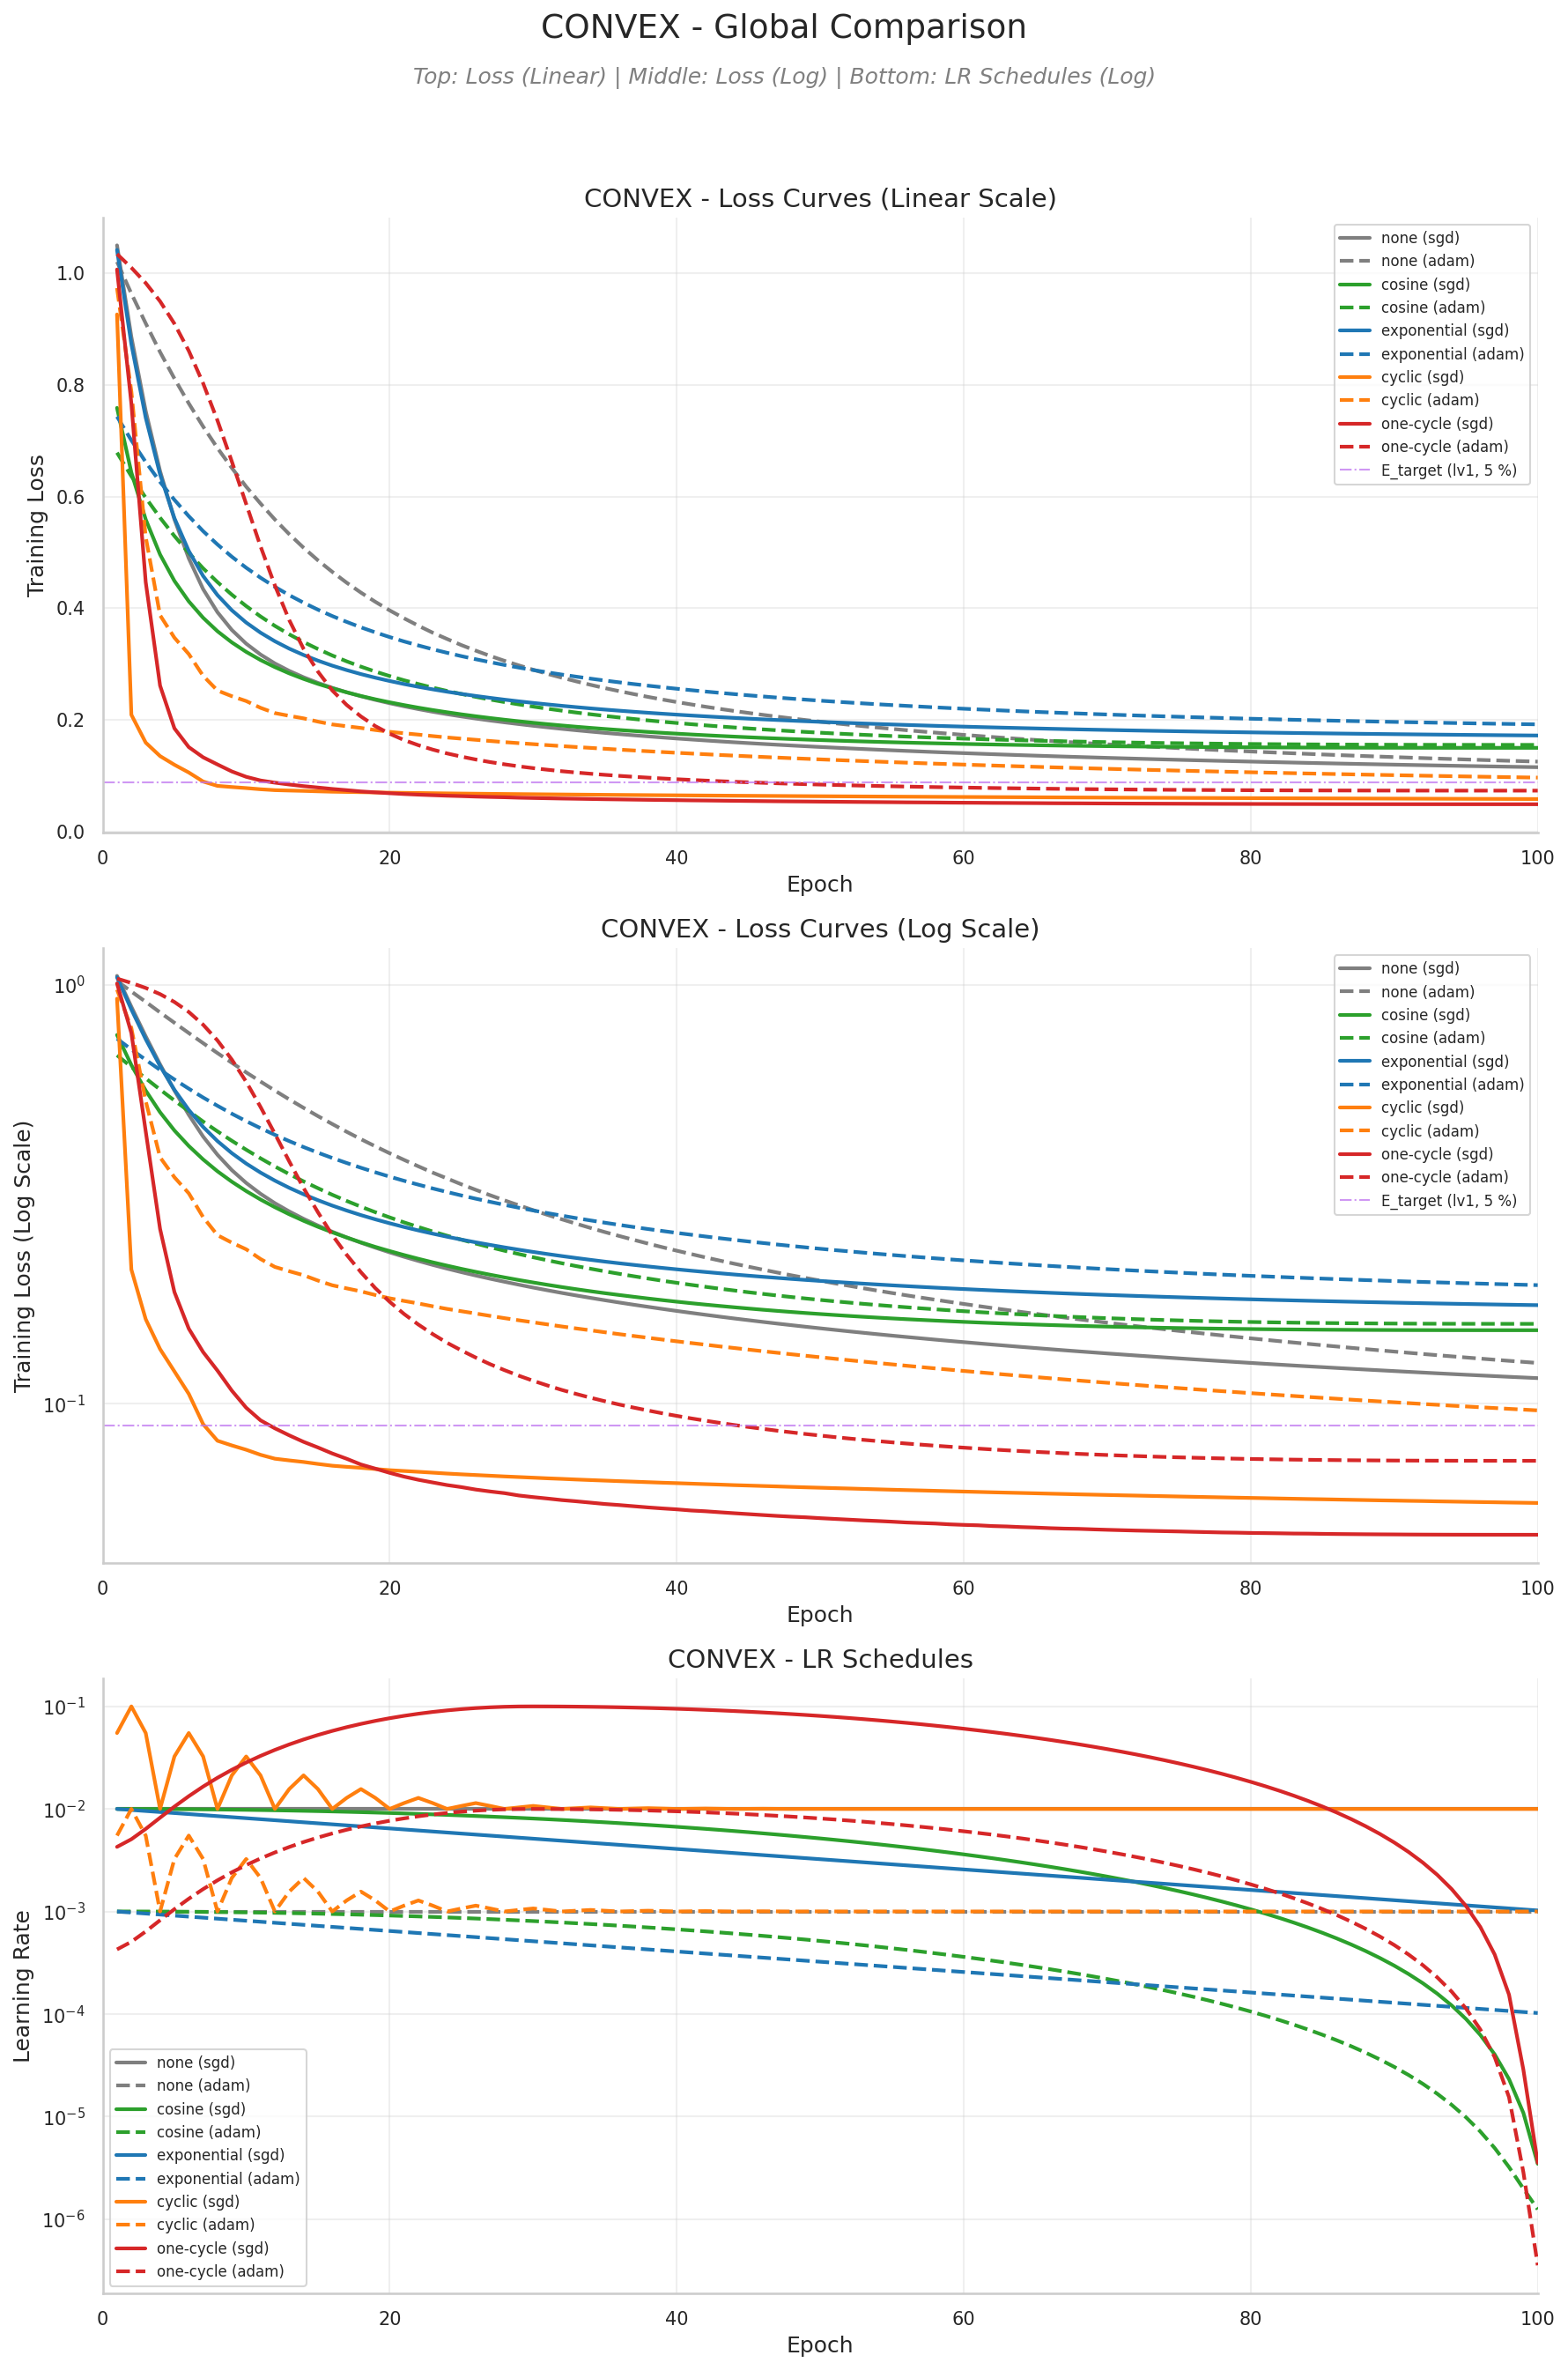

[viz] Saved: ../reports/figures/convex_level2_by_optimizer.png


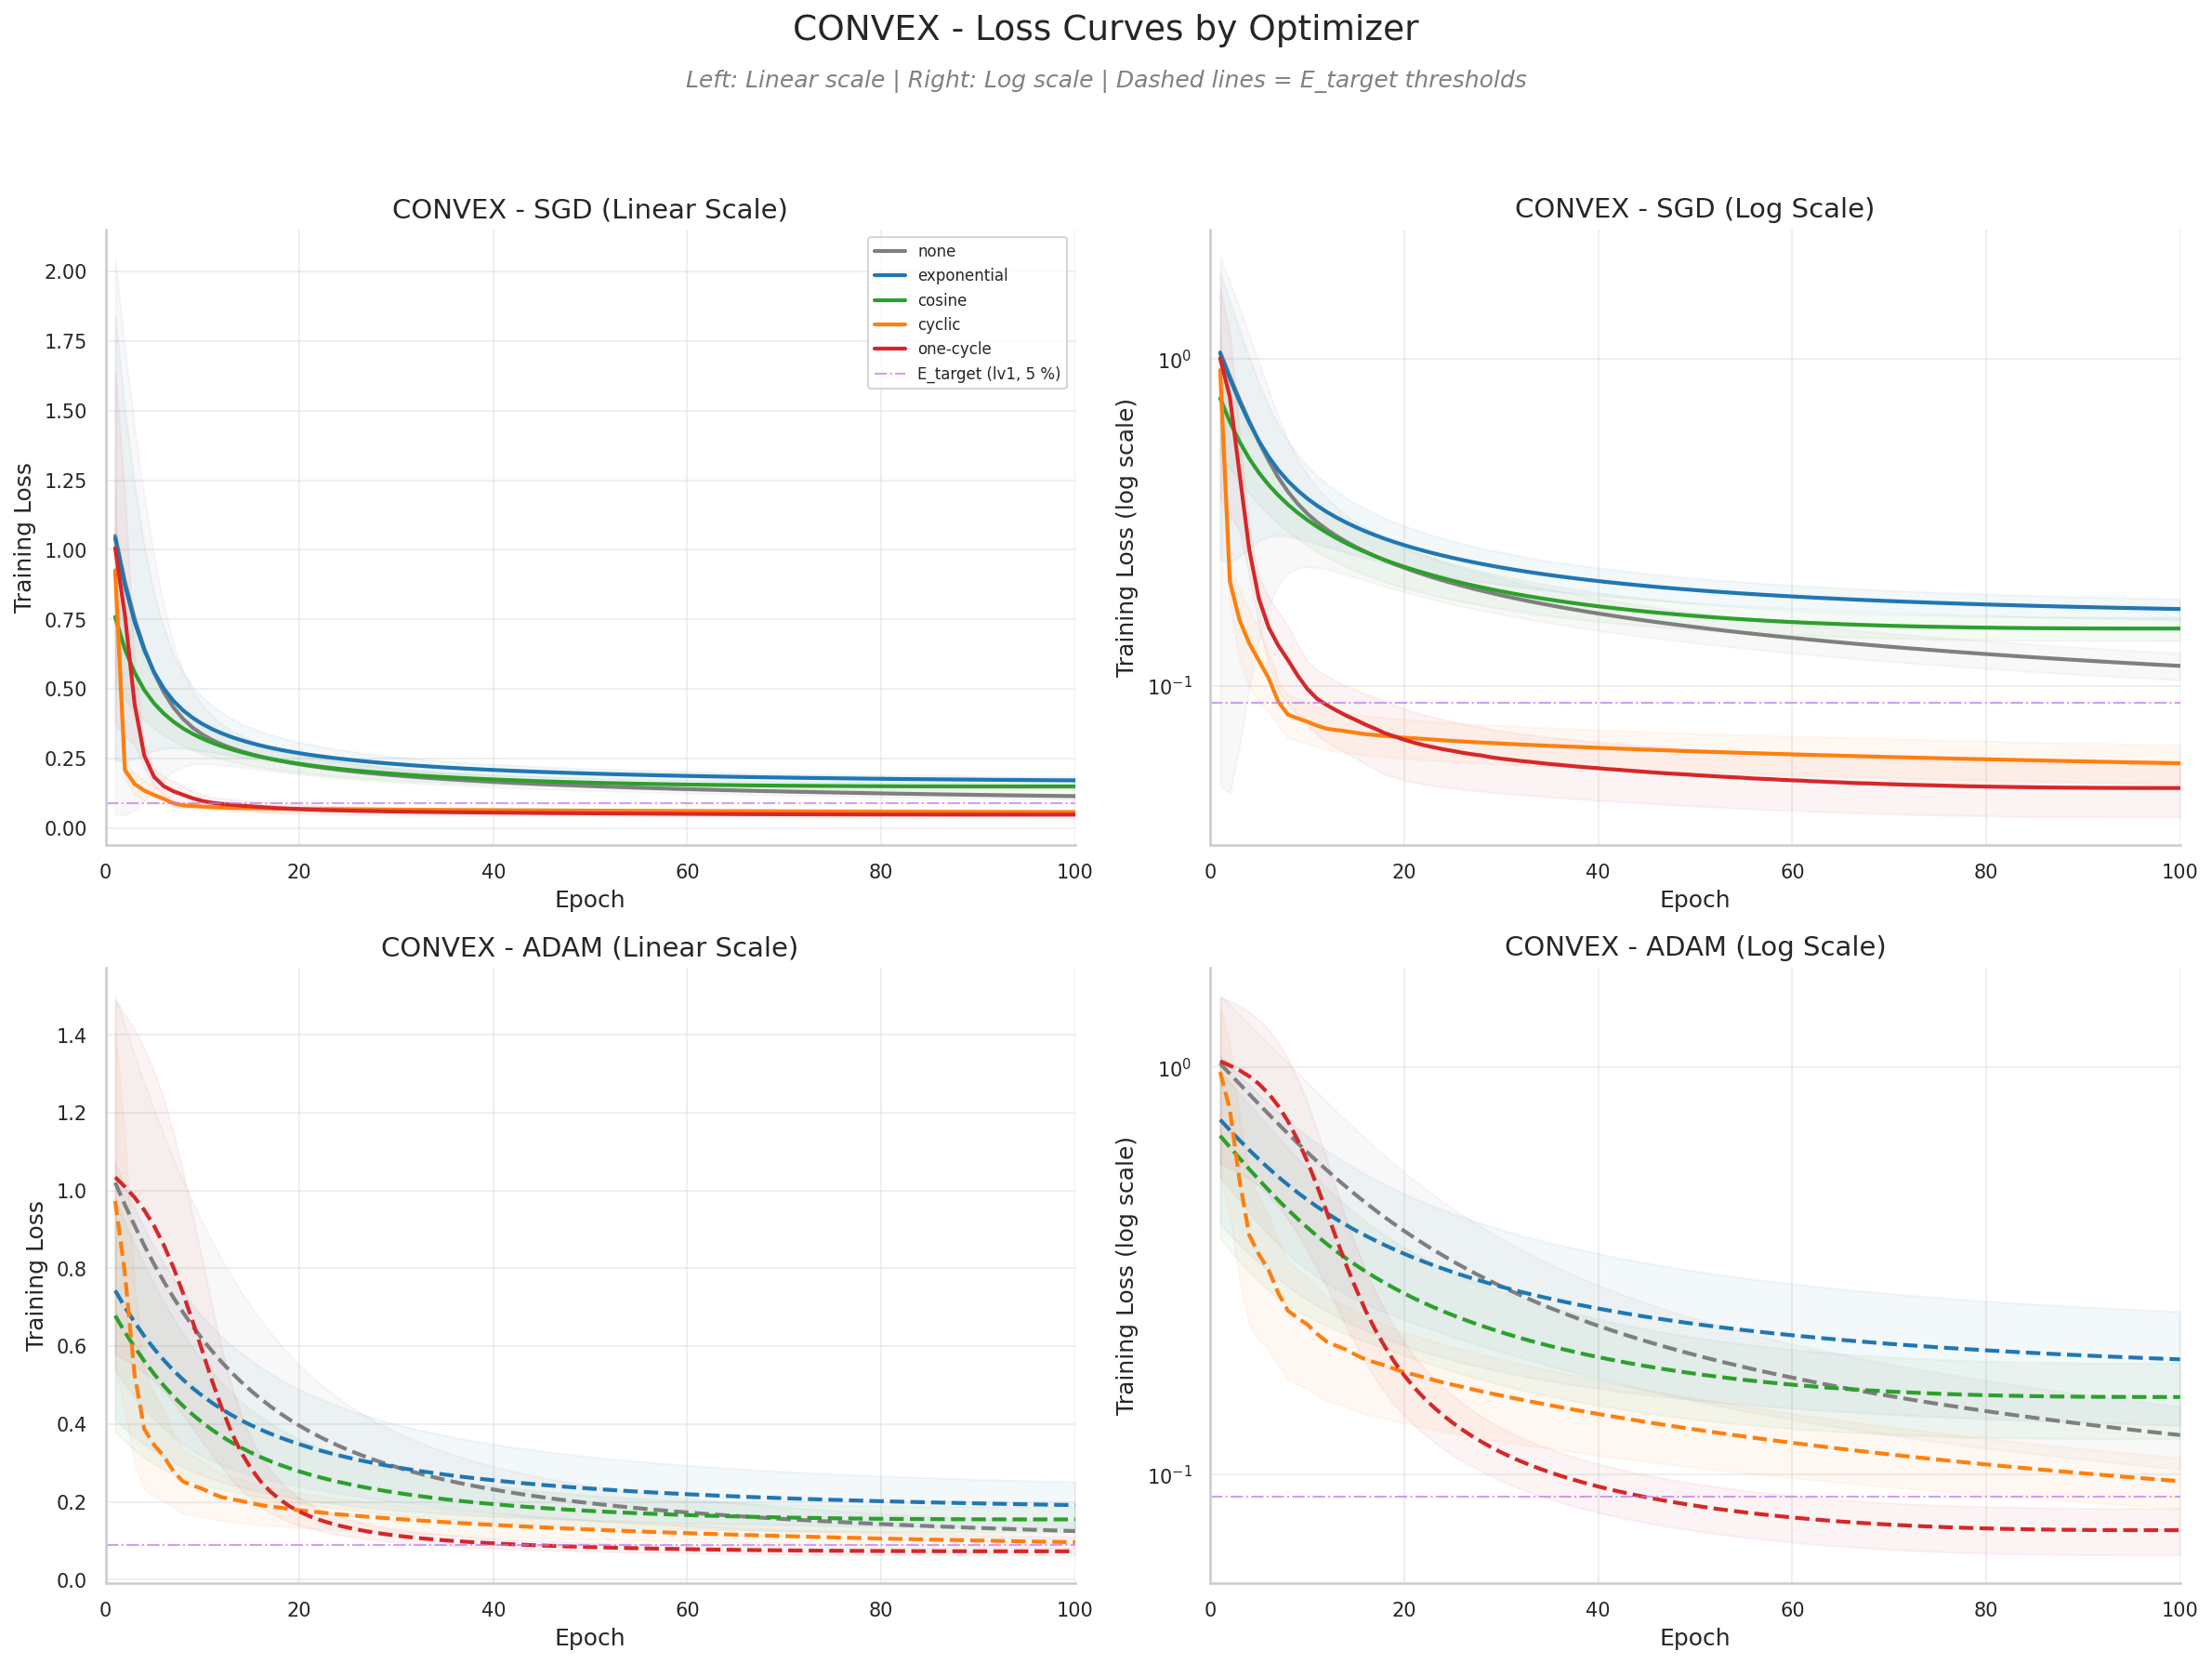

[viz] Saved: ../reports/figures/convex_level3_seed_variance.png


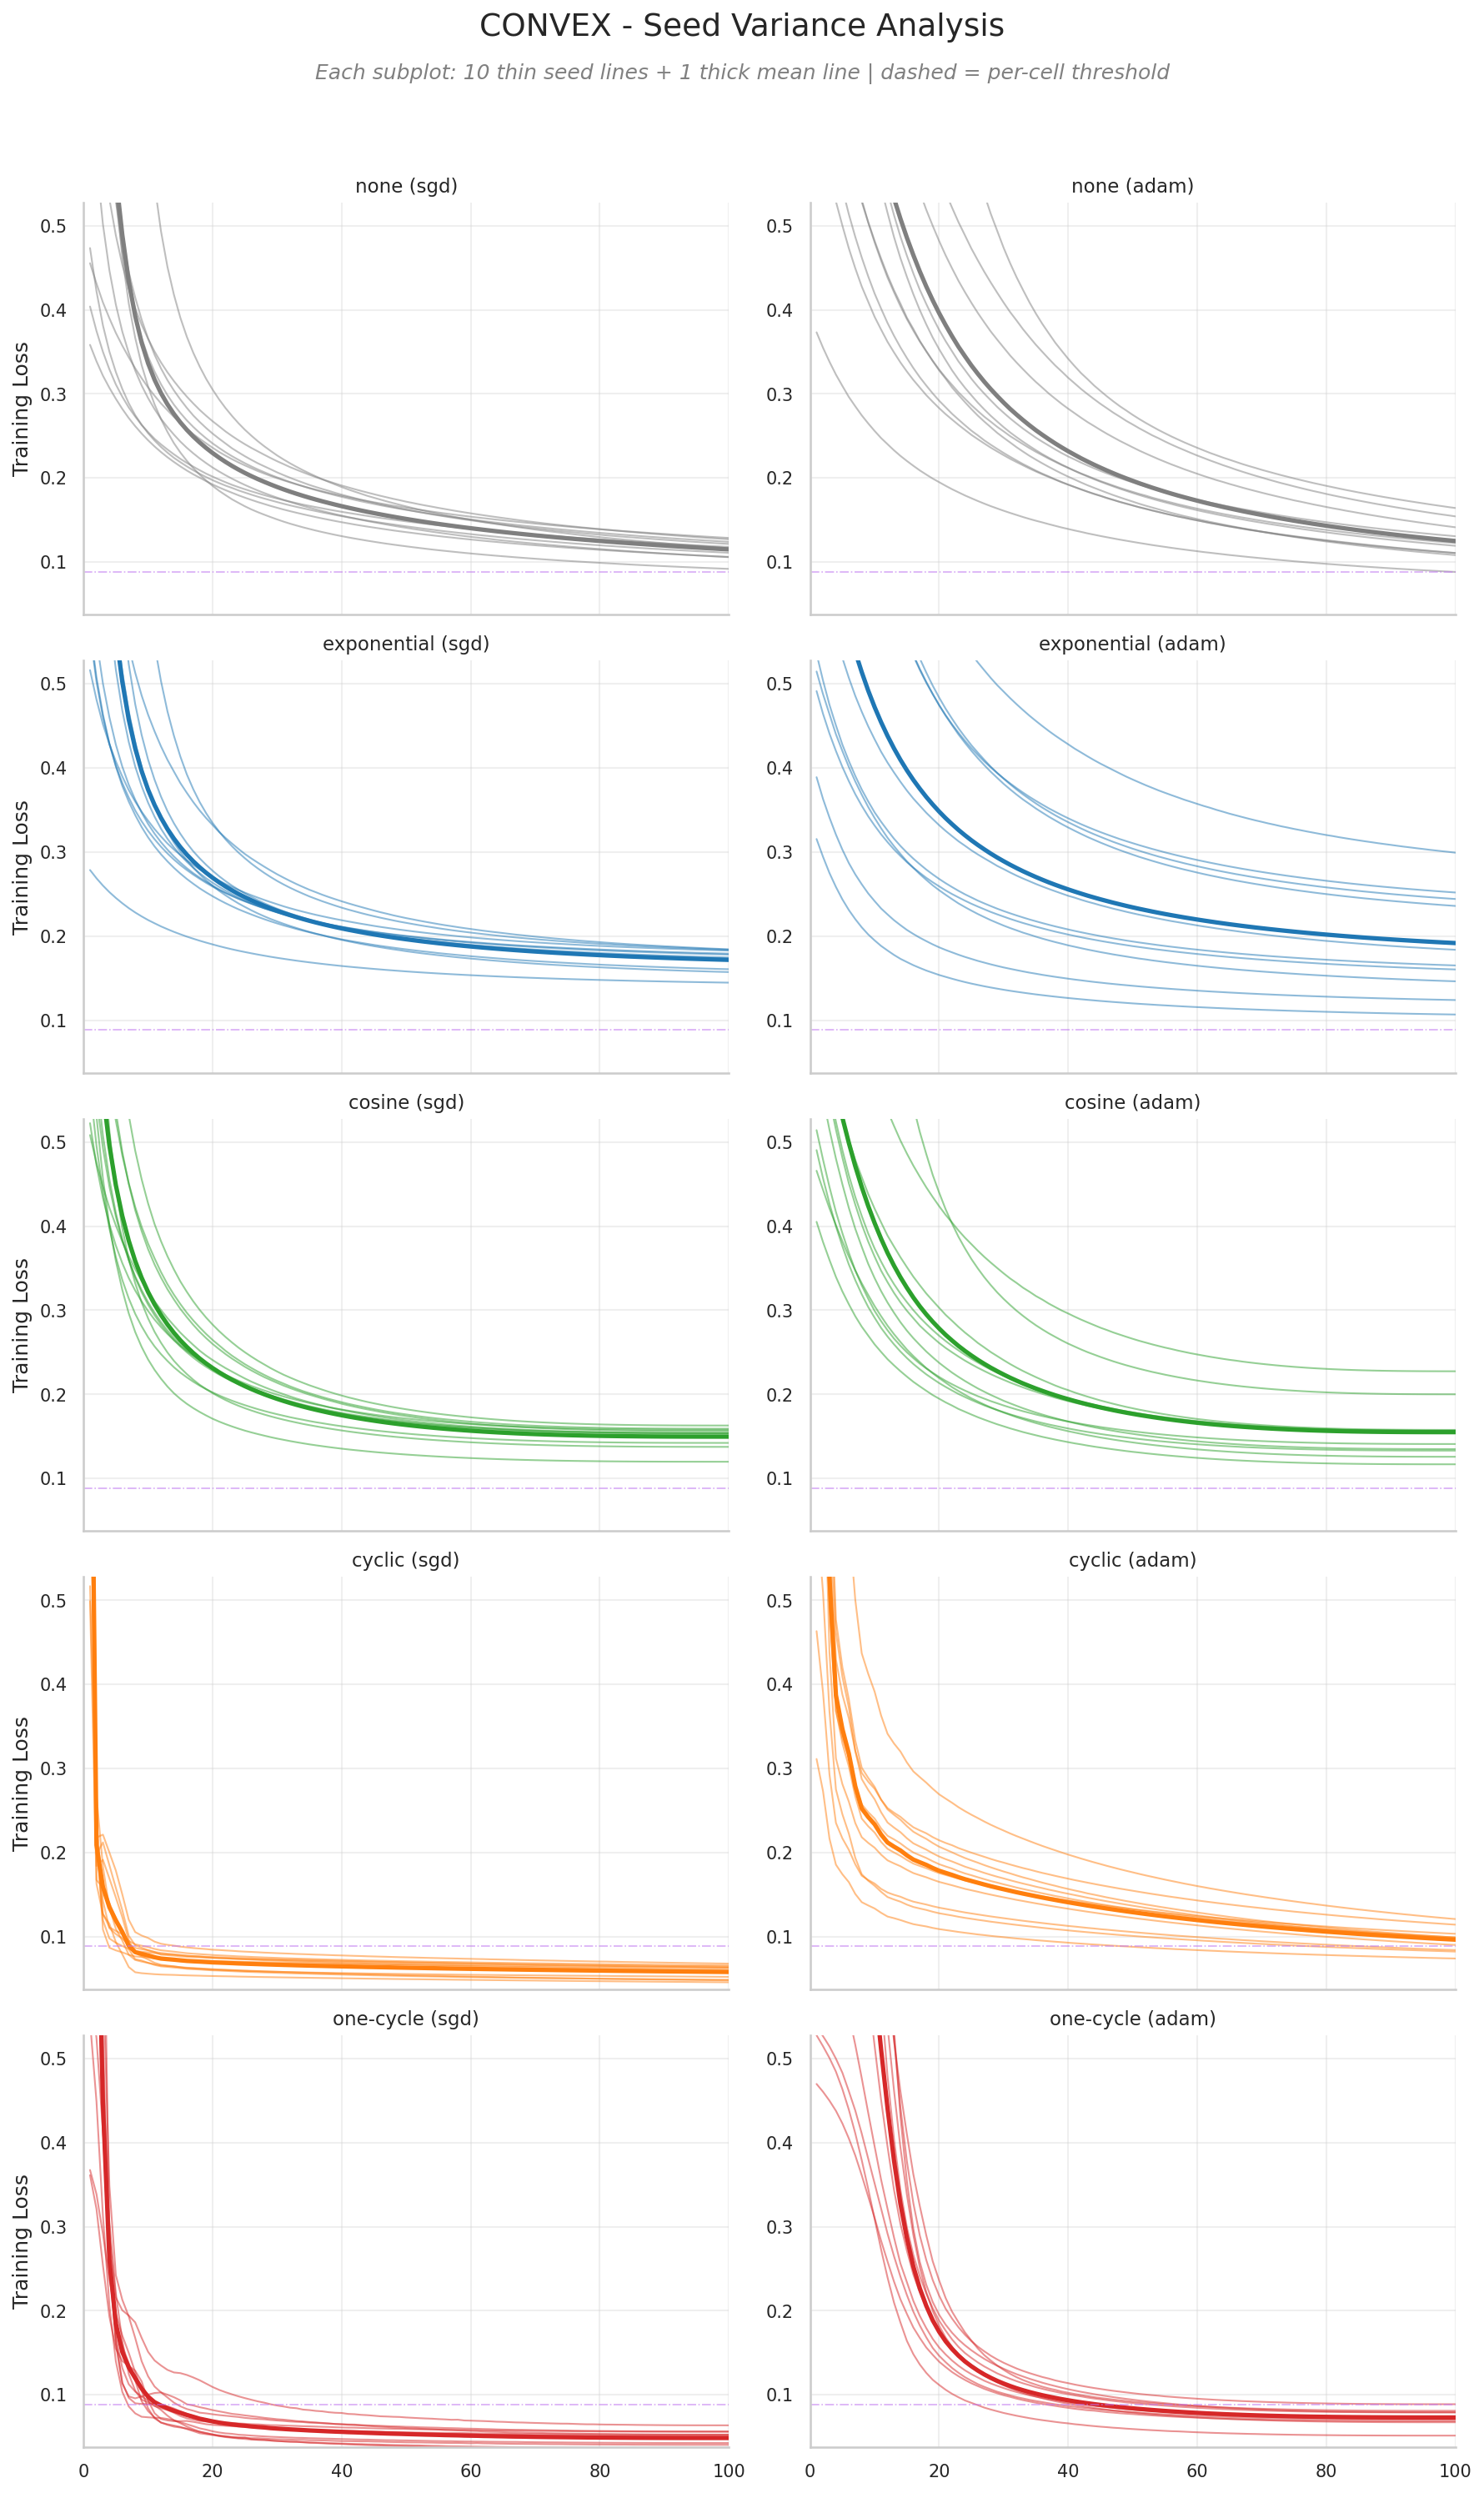

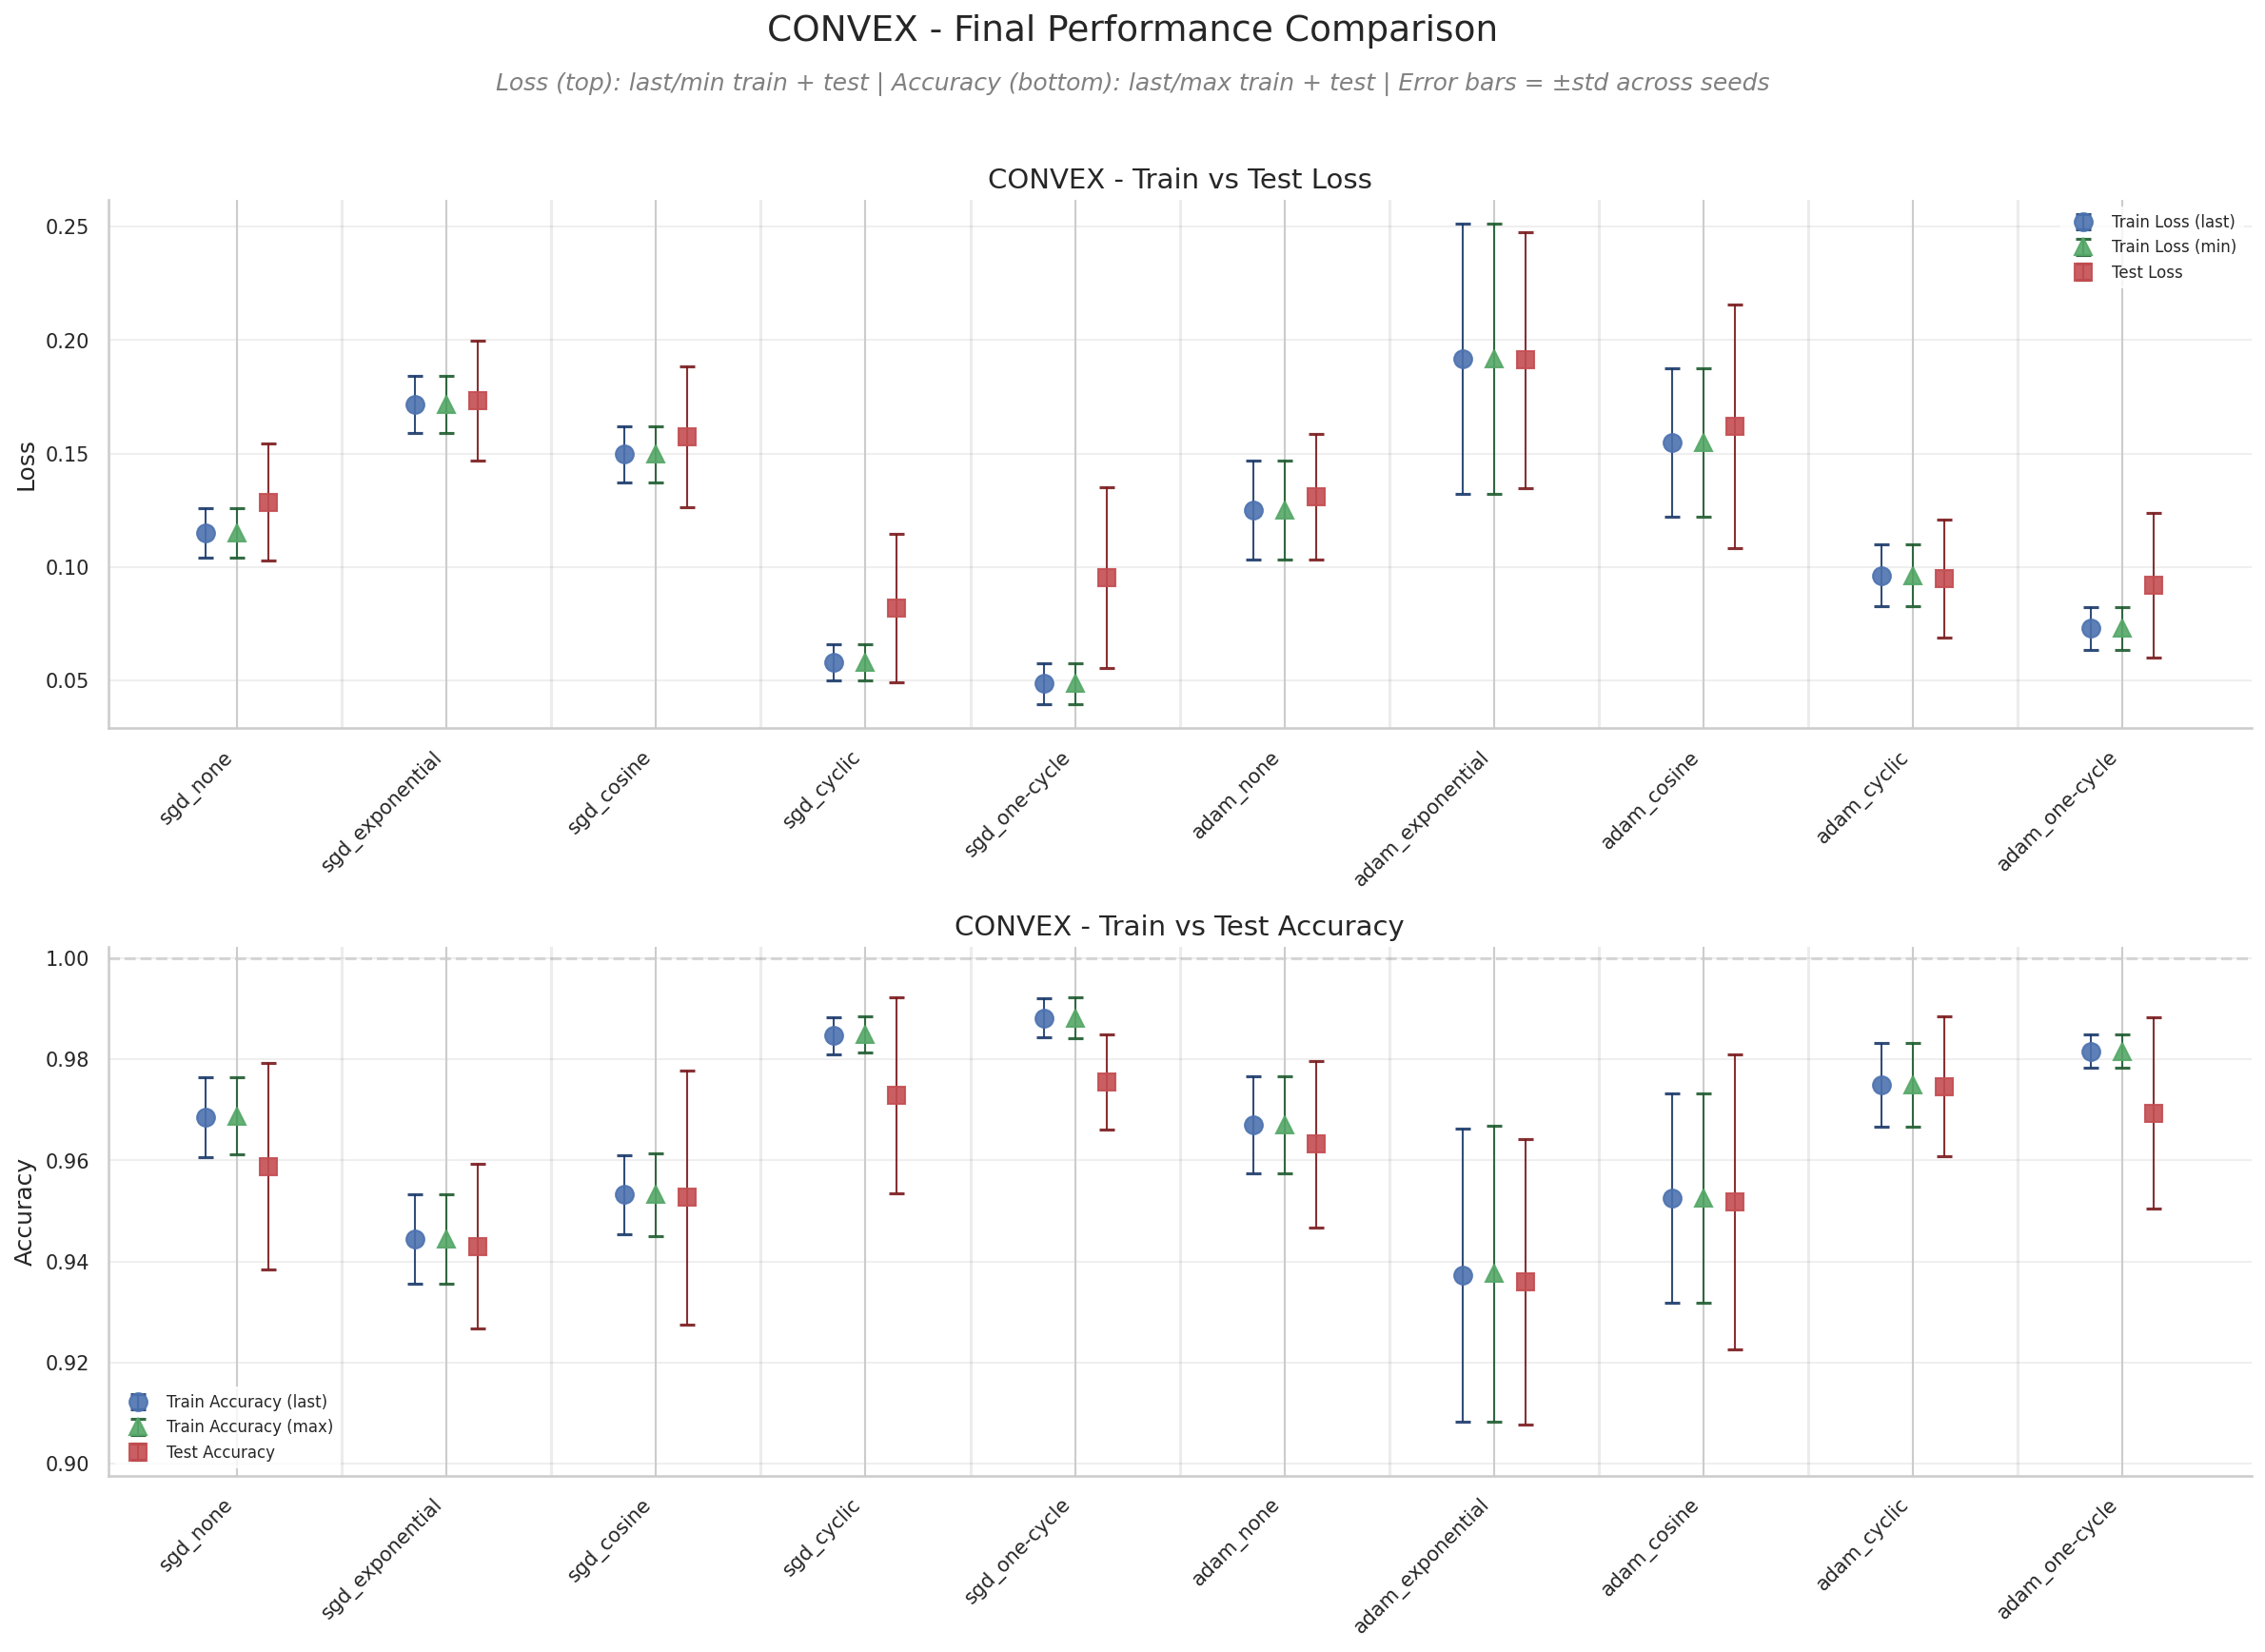

[viz] Saved: ../reports/figures/convex_analytical_a_loss_lr_dual.png


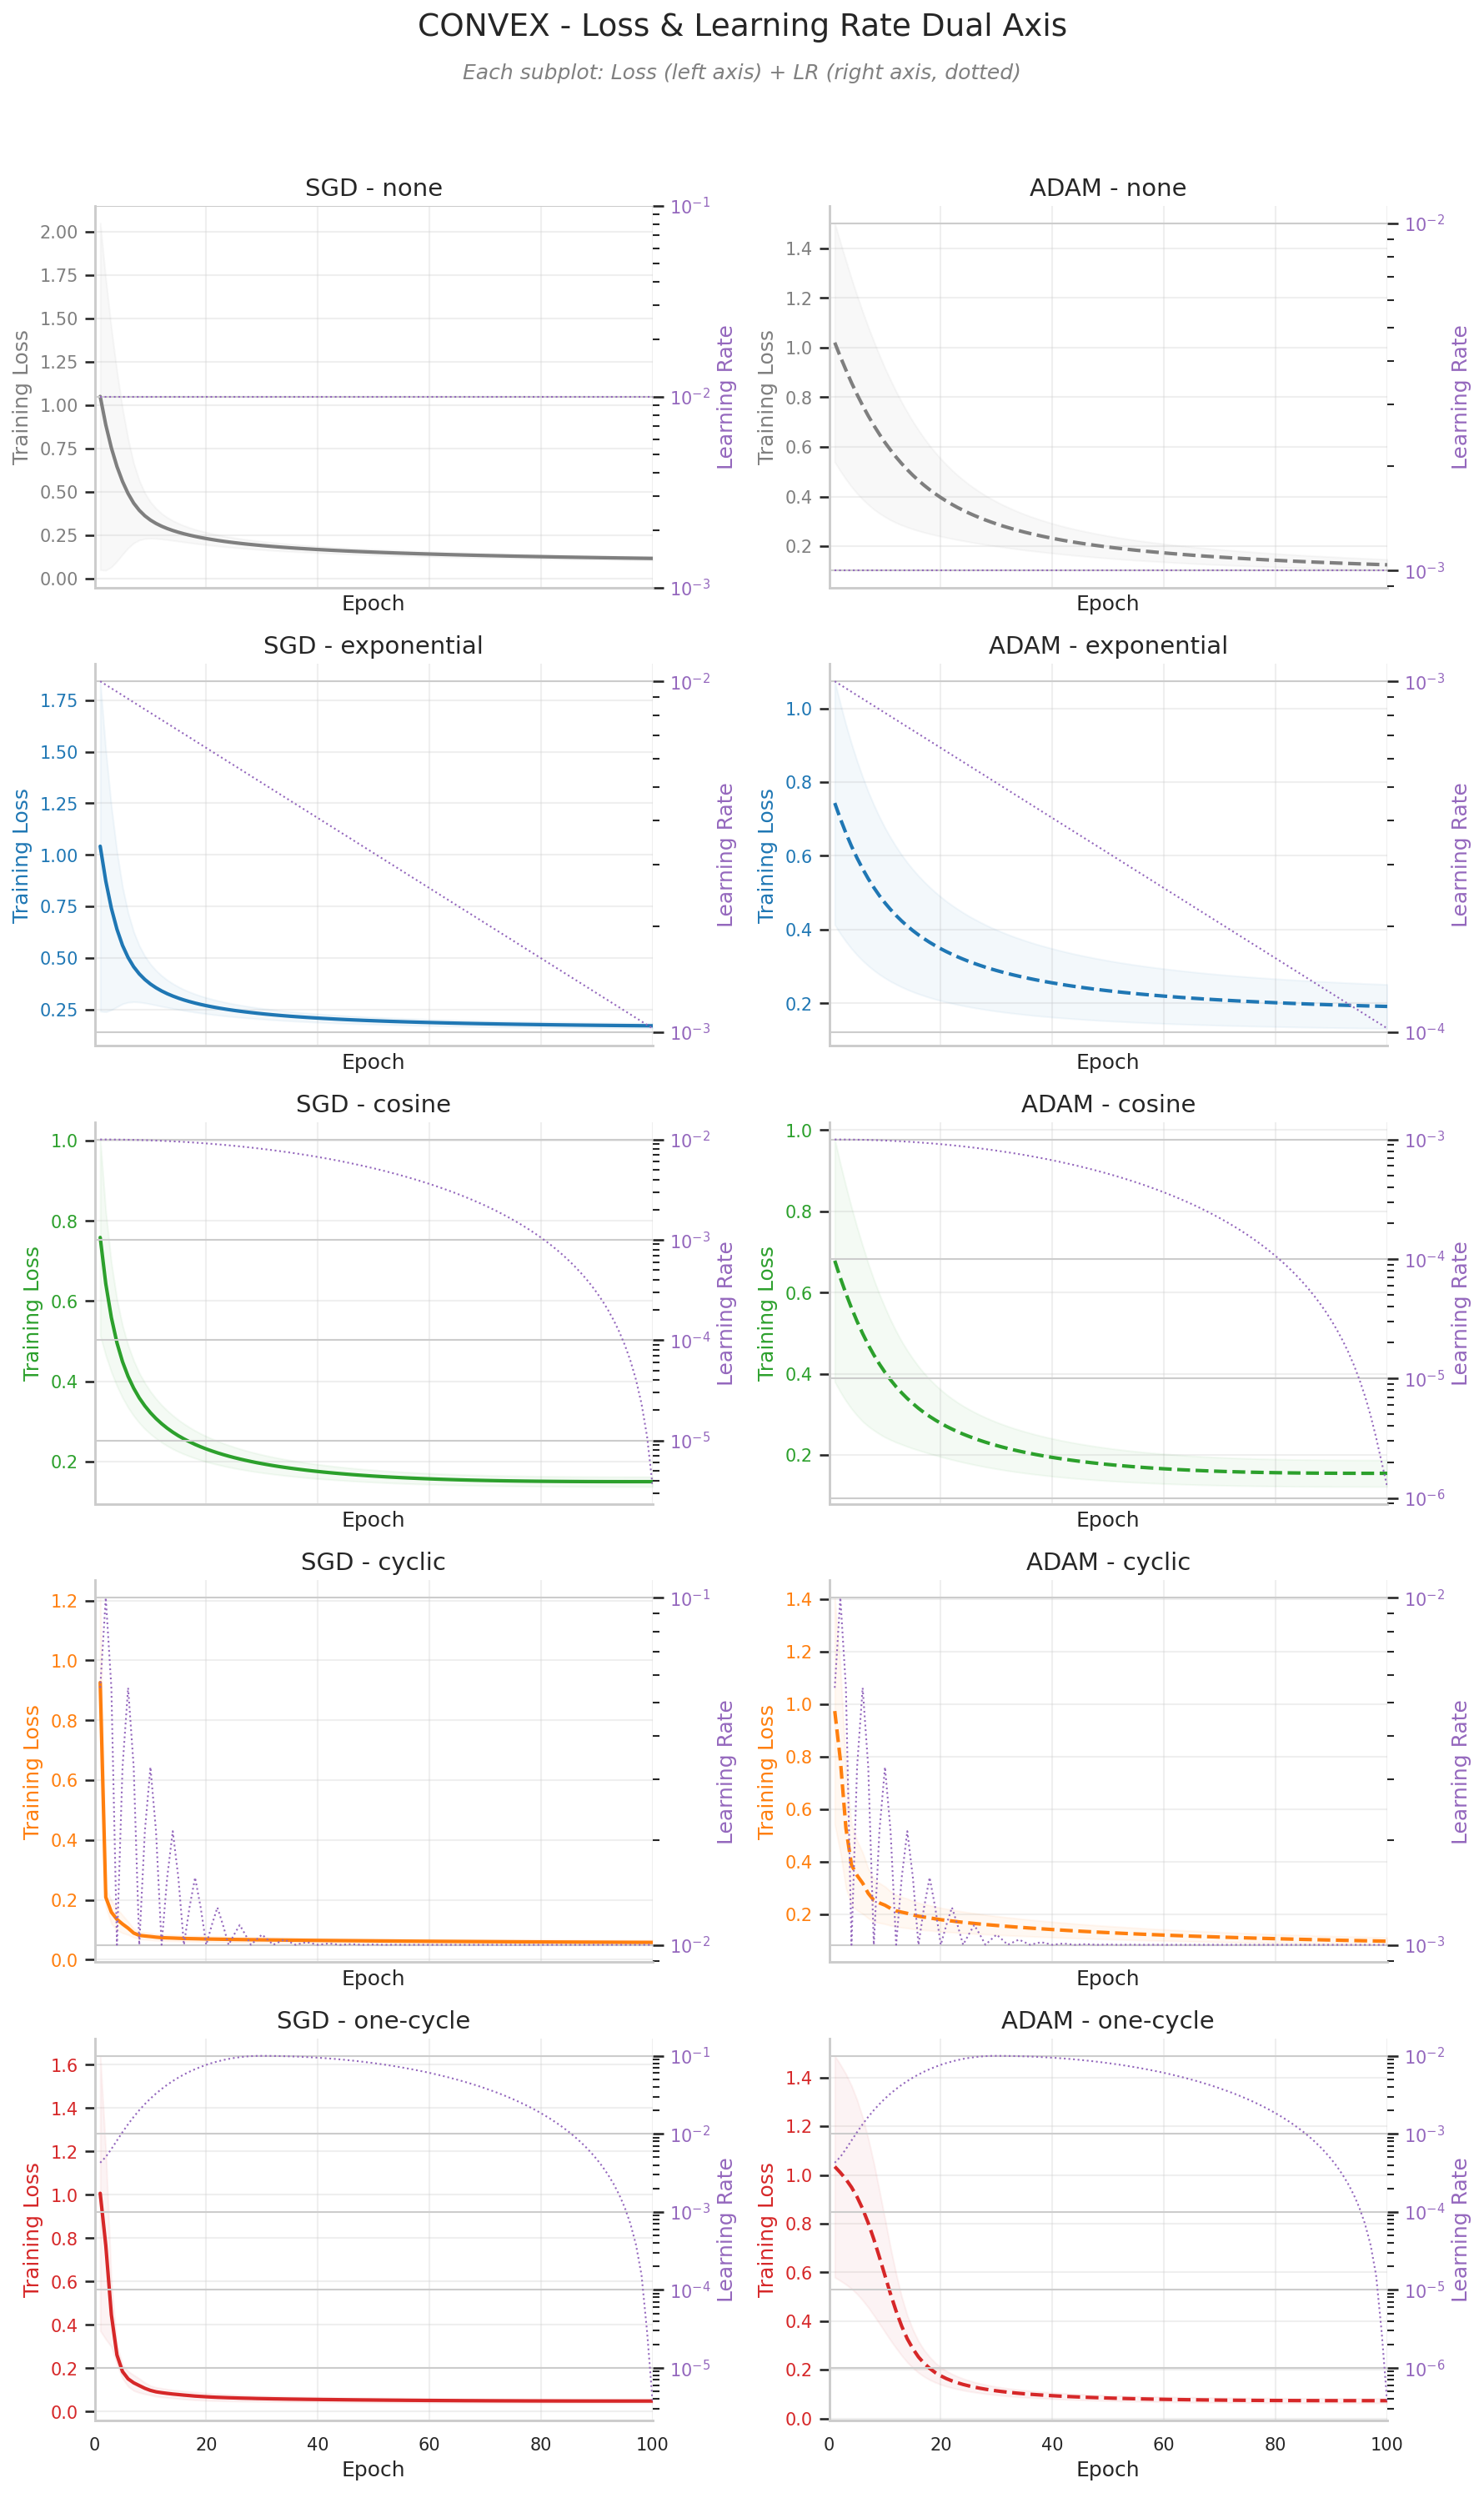

[viz] All plots saved for: convex
[viz] Generating all plots for: non-convex


Saved 5 plot files:
  - ../reports/figures/convex_level1_global_comparison.png
  - ../reports/figures/convex_level2_by_optimizer.png
  - ../reports/figures/convex_level3_seed_variance.png
  - ../reports/figures/convex_level4_final_performance.png
  - ../reports/figures/convex_analytical_a_loss_lr_dual.png

Generating plots for: NON-CONVEX
L_star = 0.001996, L0 = 0.610189


[viz] Saved: ../reports/figures/non-convex_level1_global_comparison.png


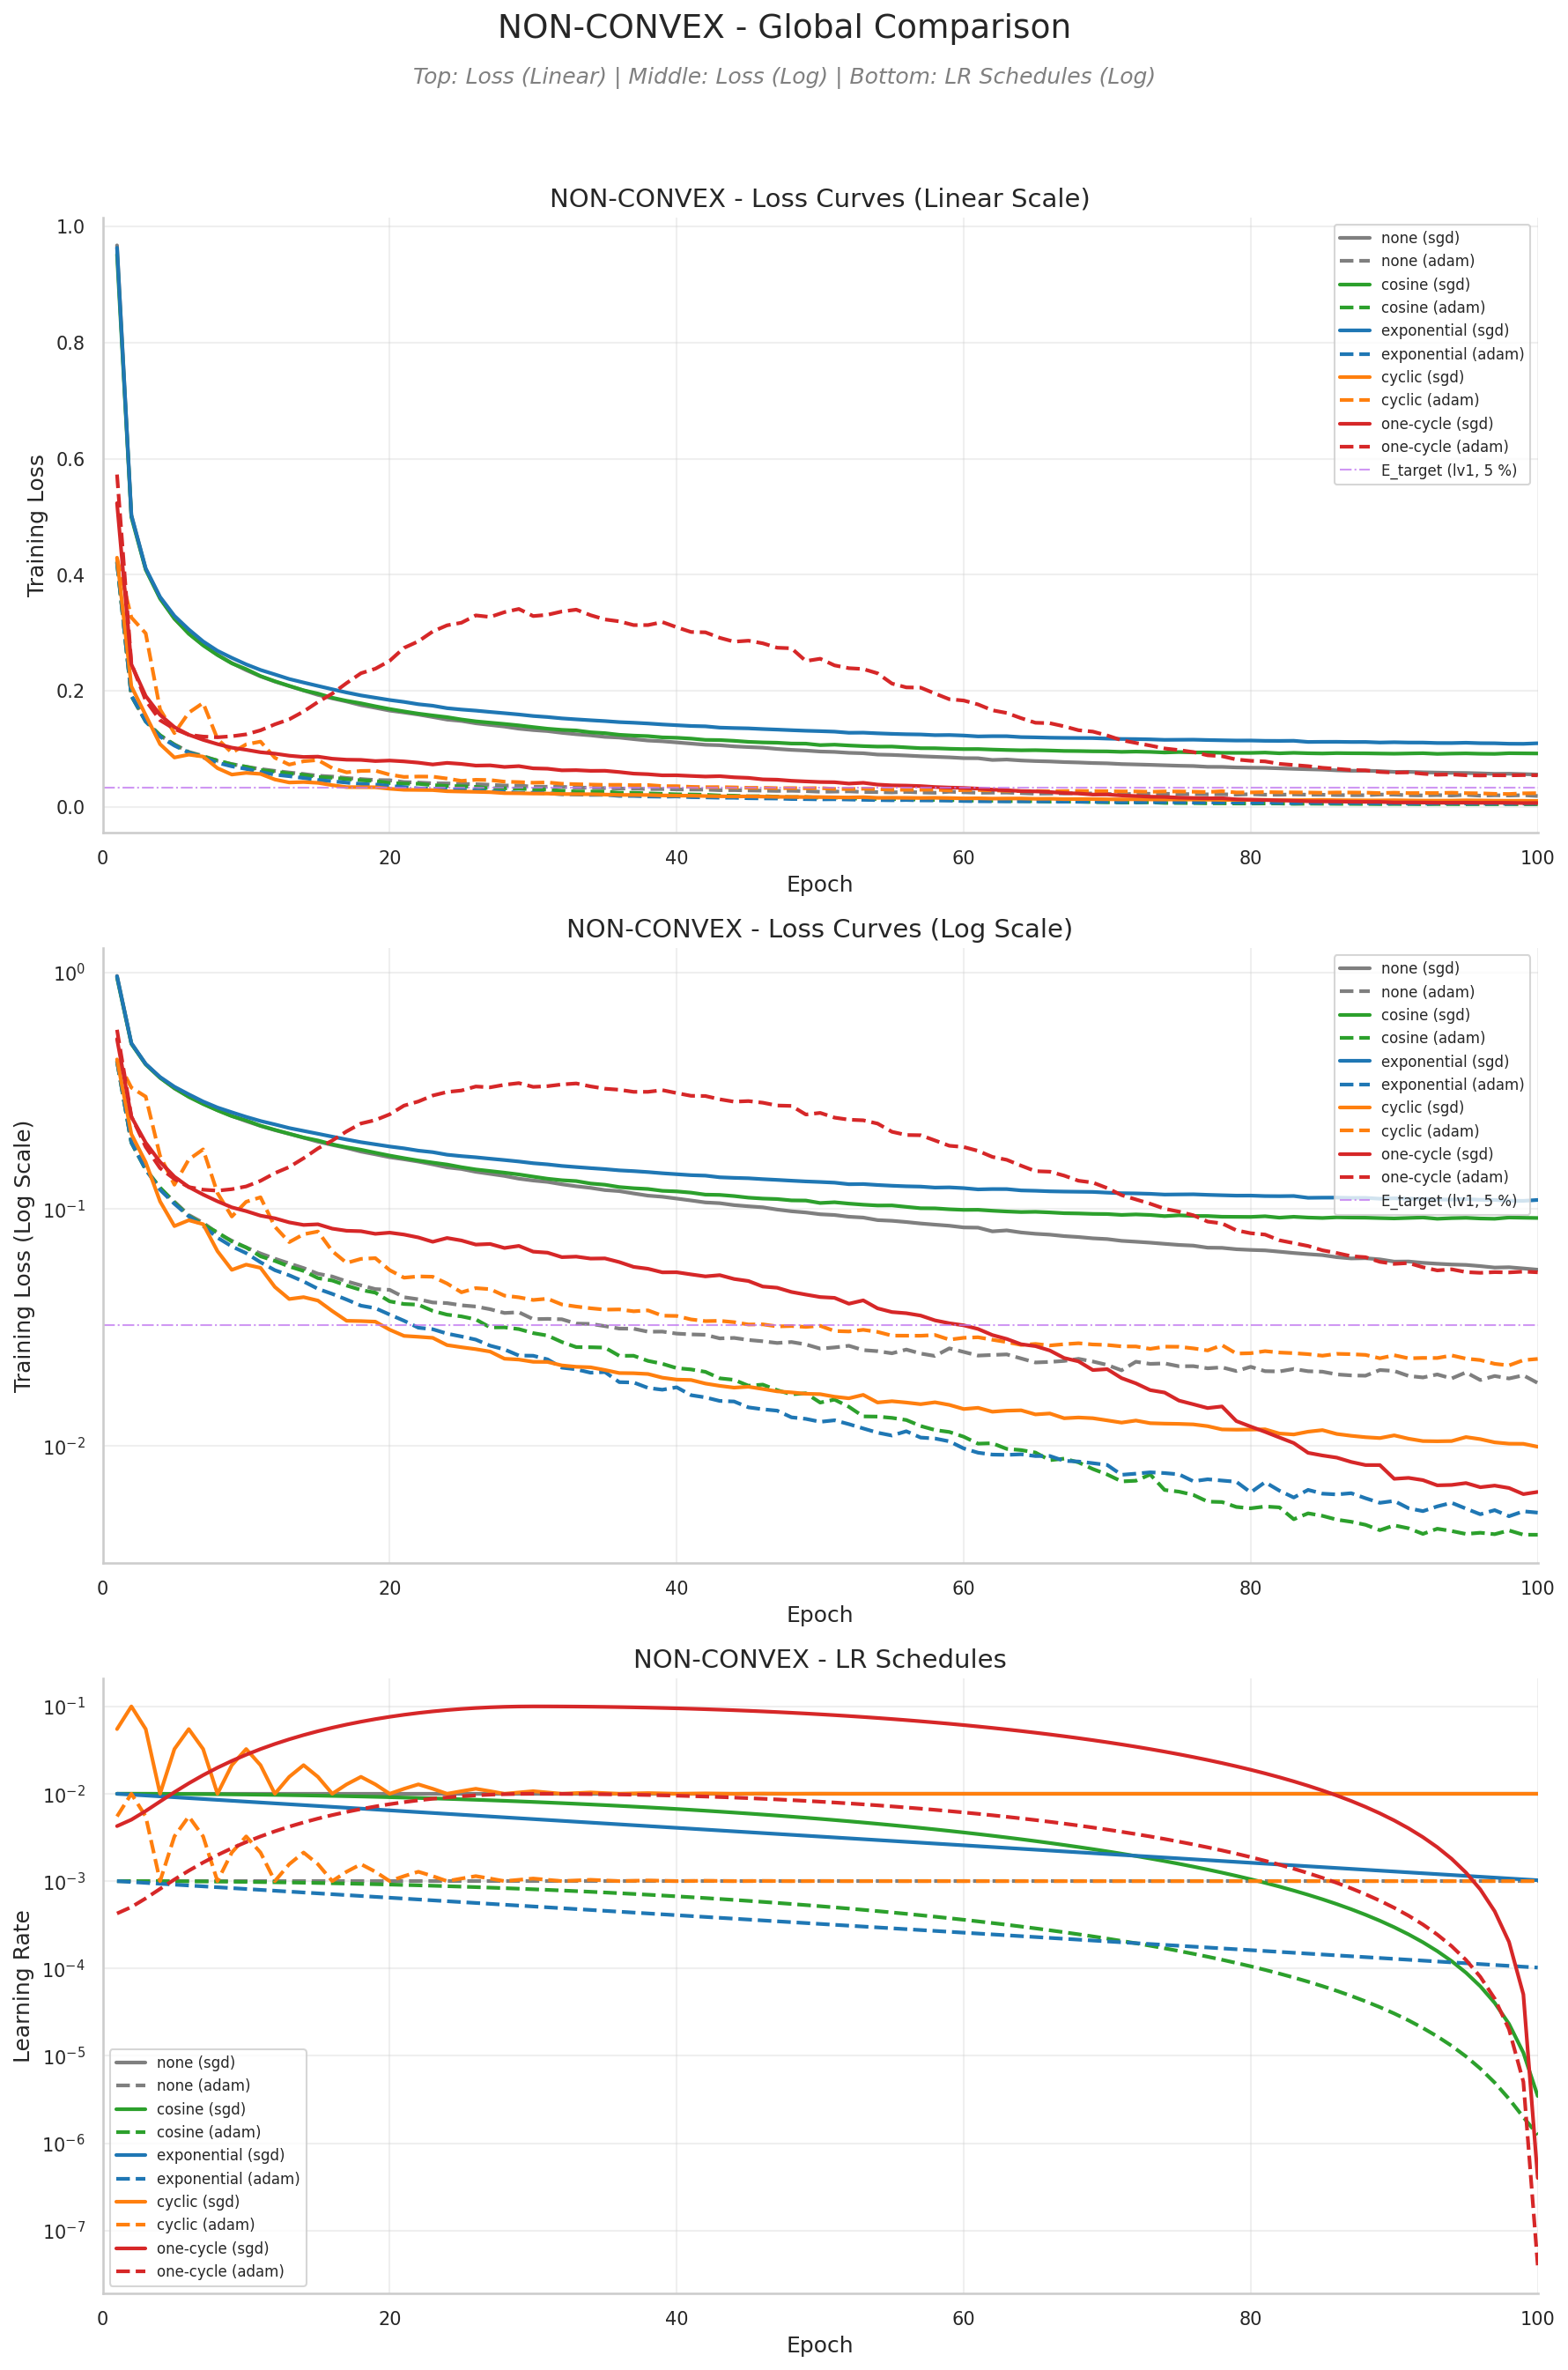

[viz] Saved: ../reports/figures/non-convex_level2_by_optimizer.png


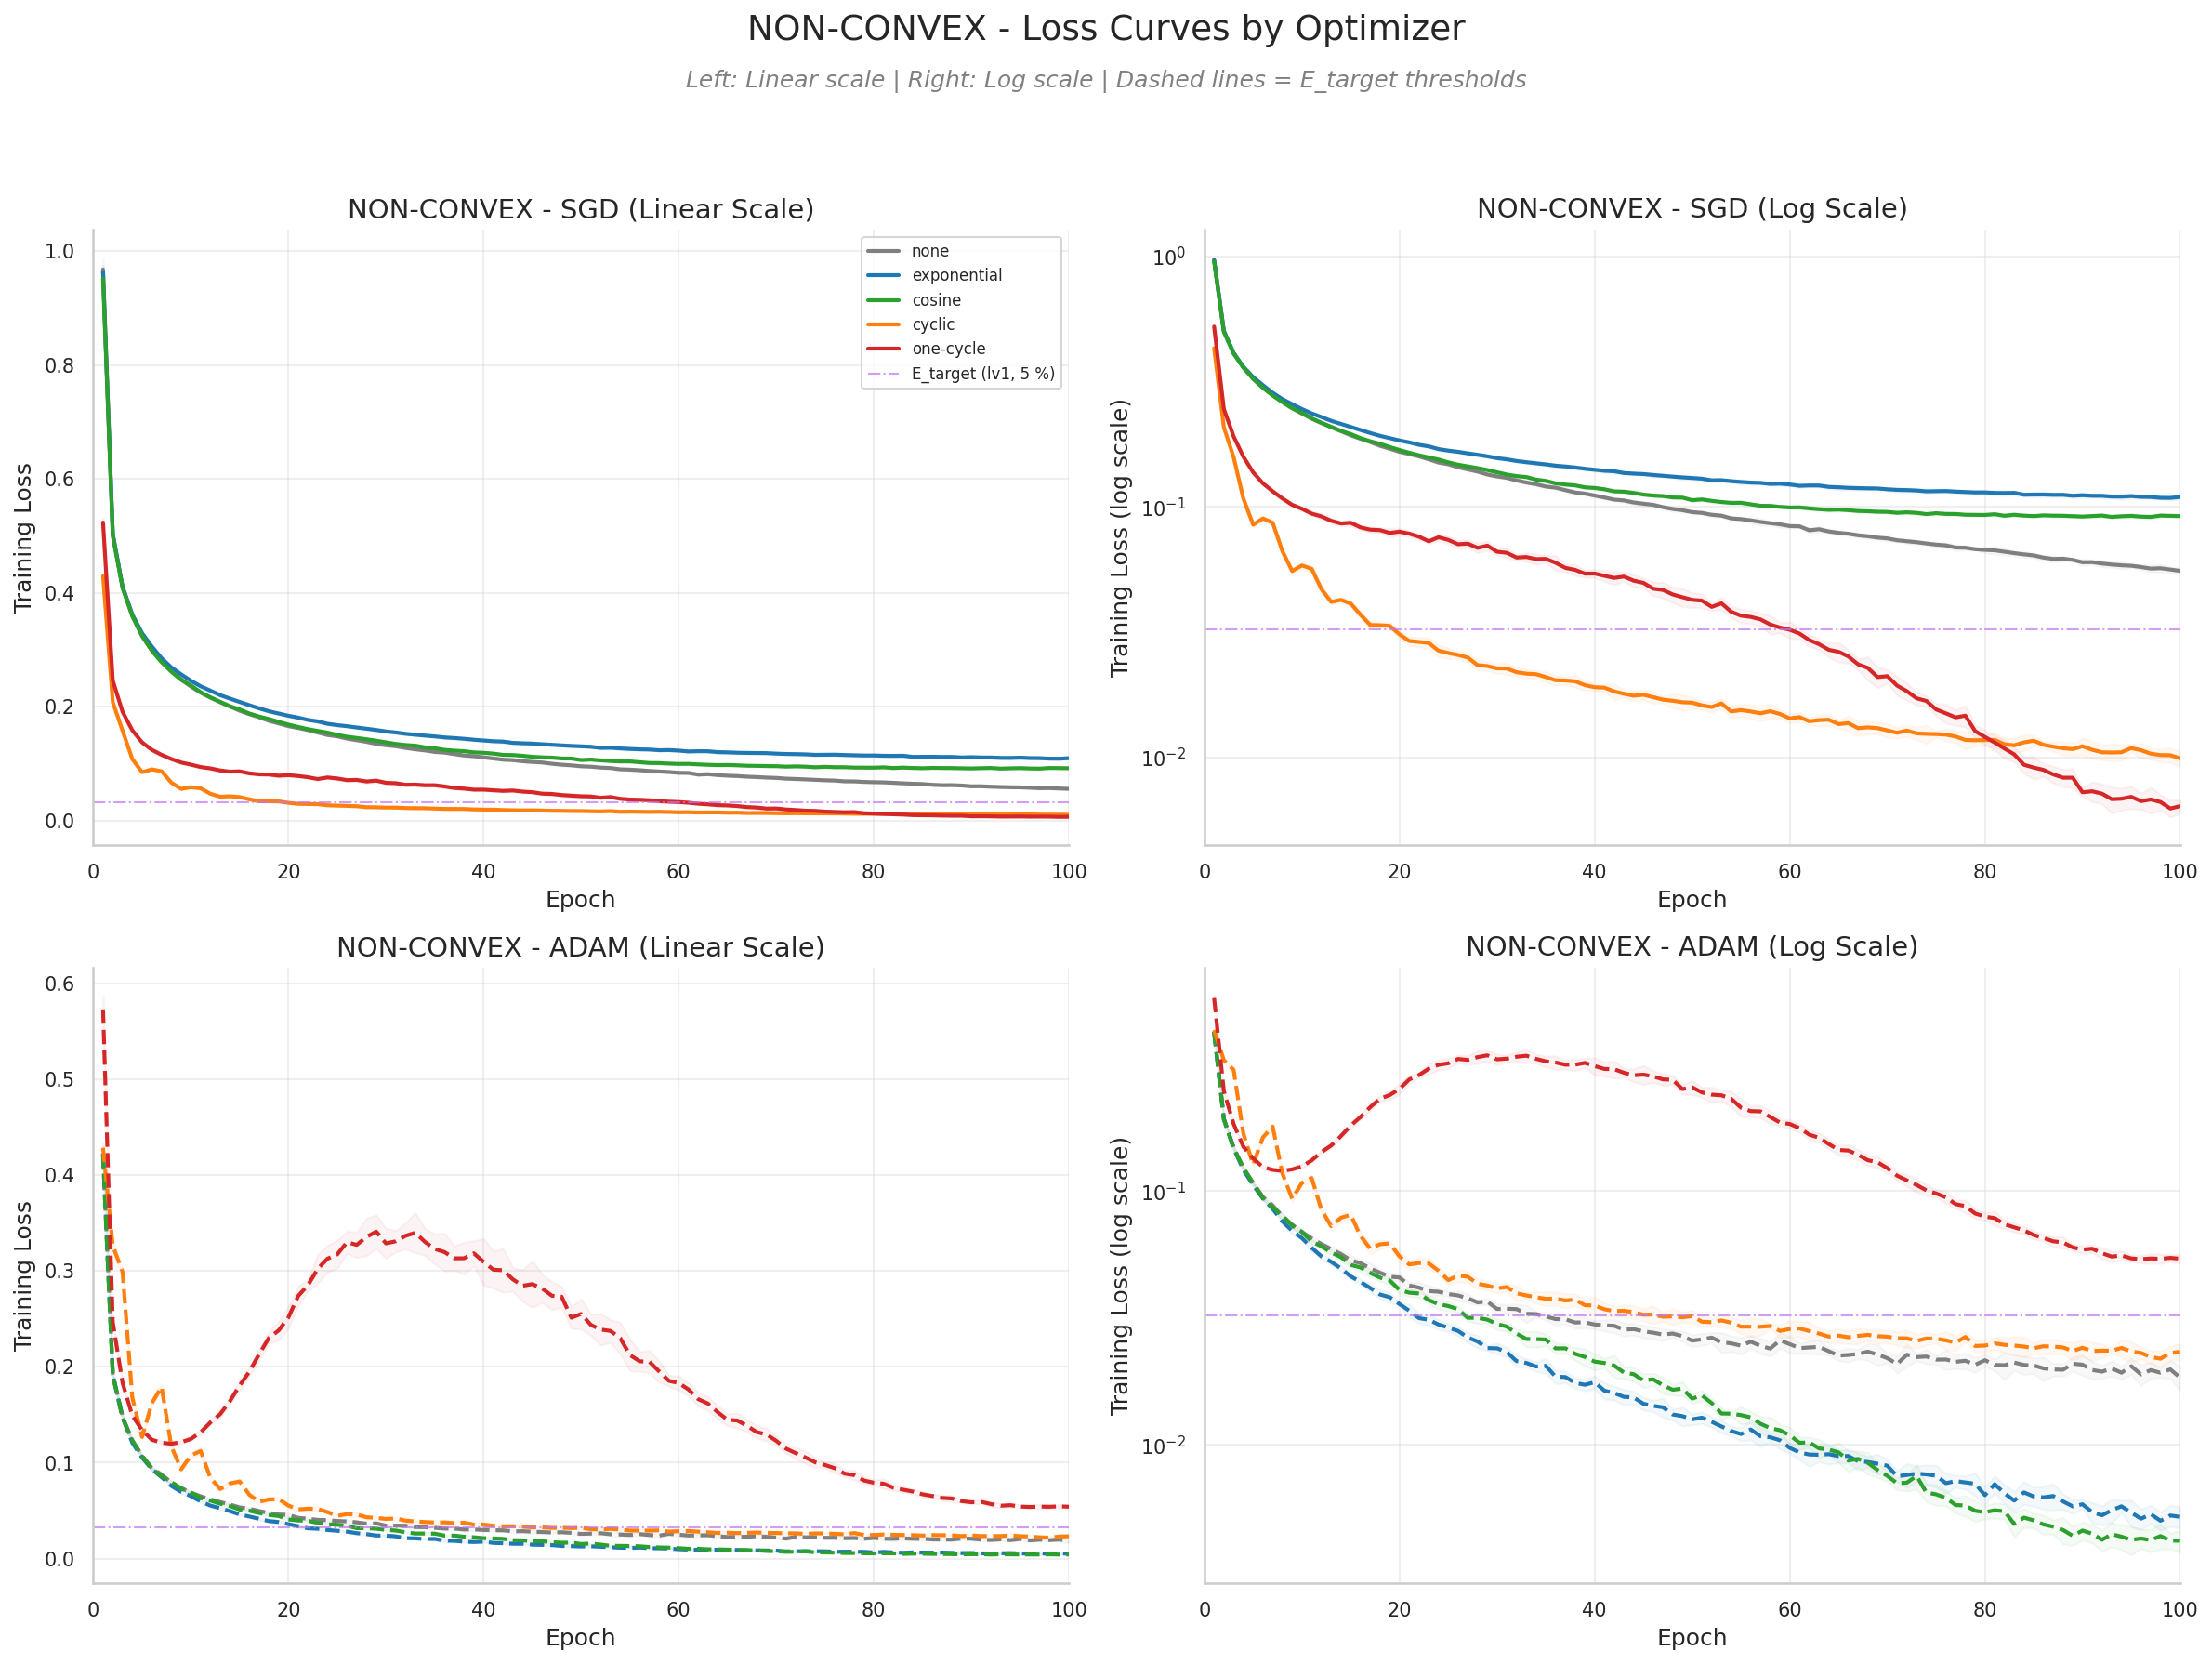

[viz] Saved: ../reports/figures/non-convex_level3_seed_variance.png


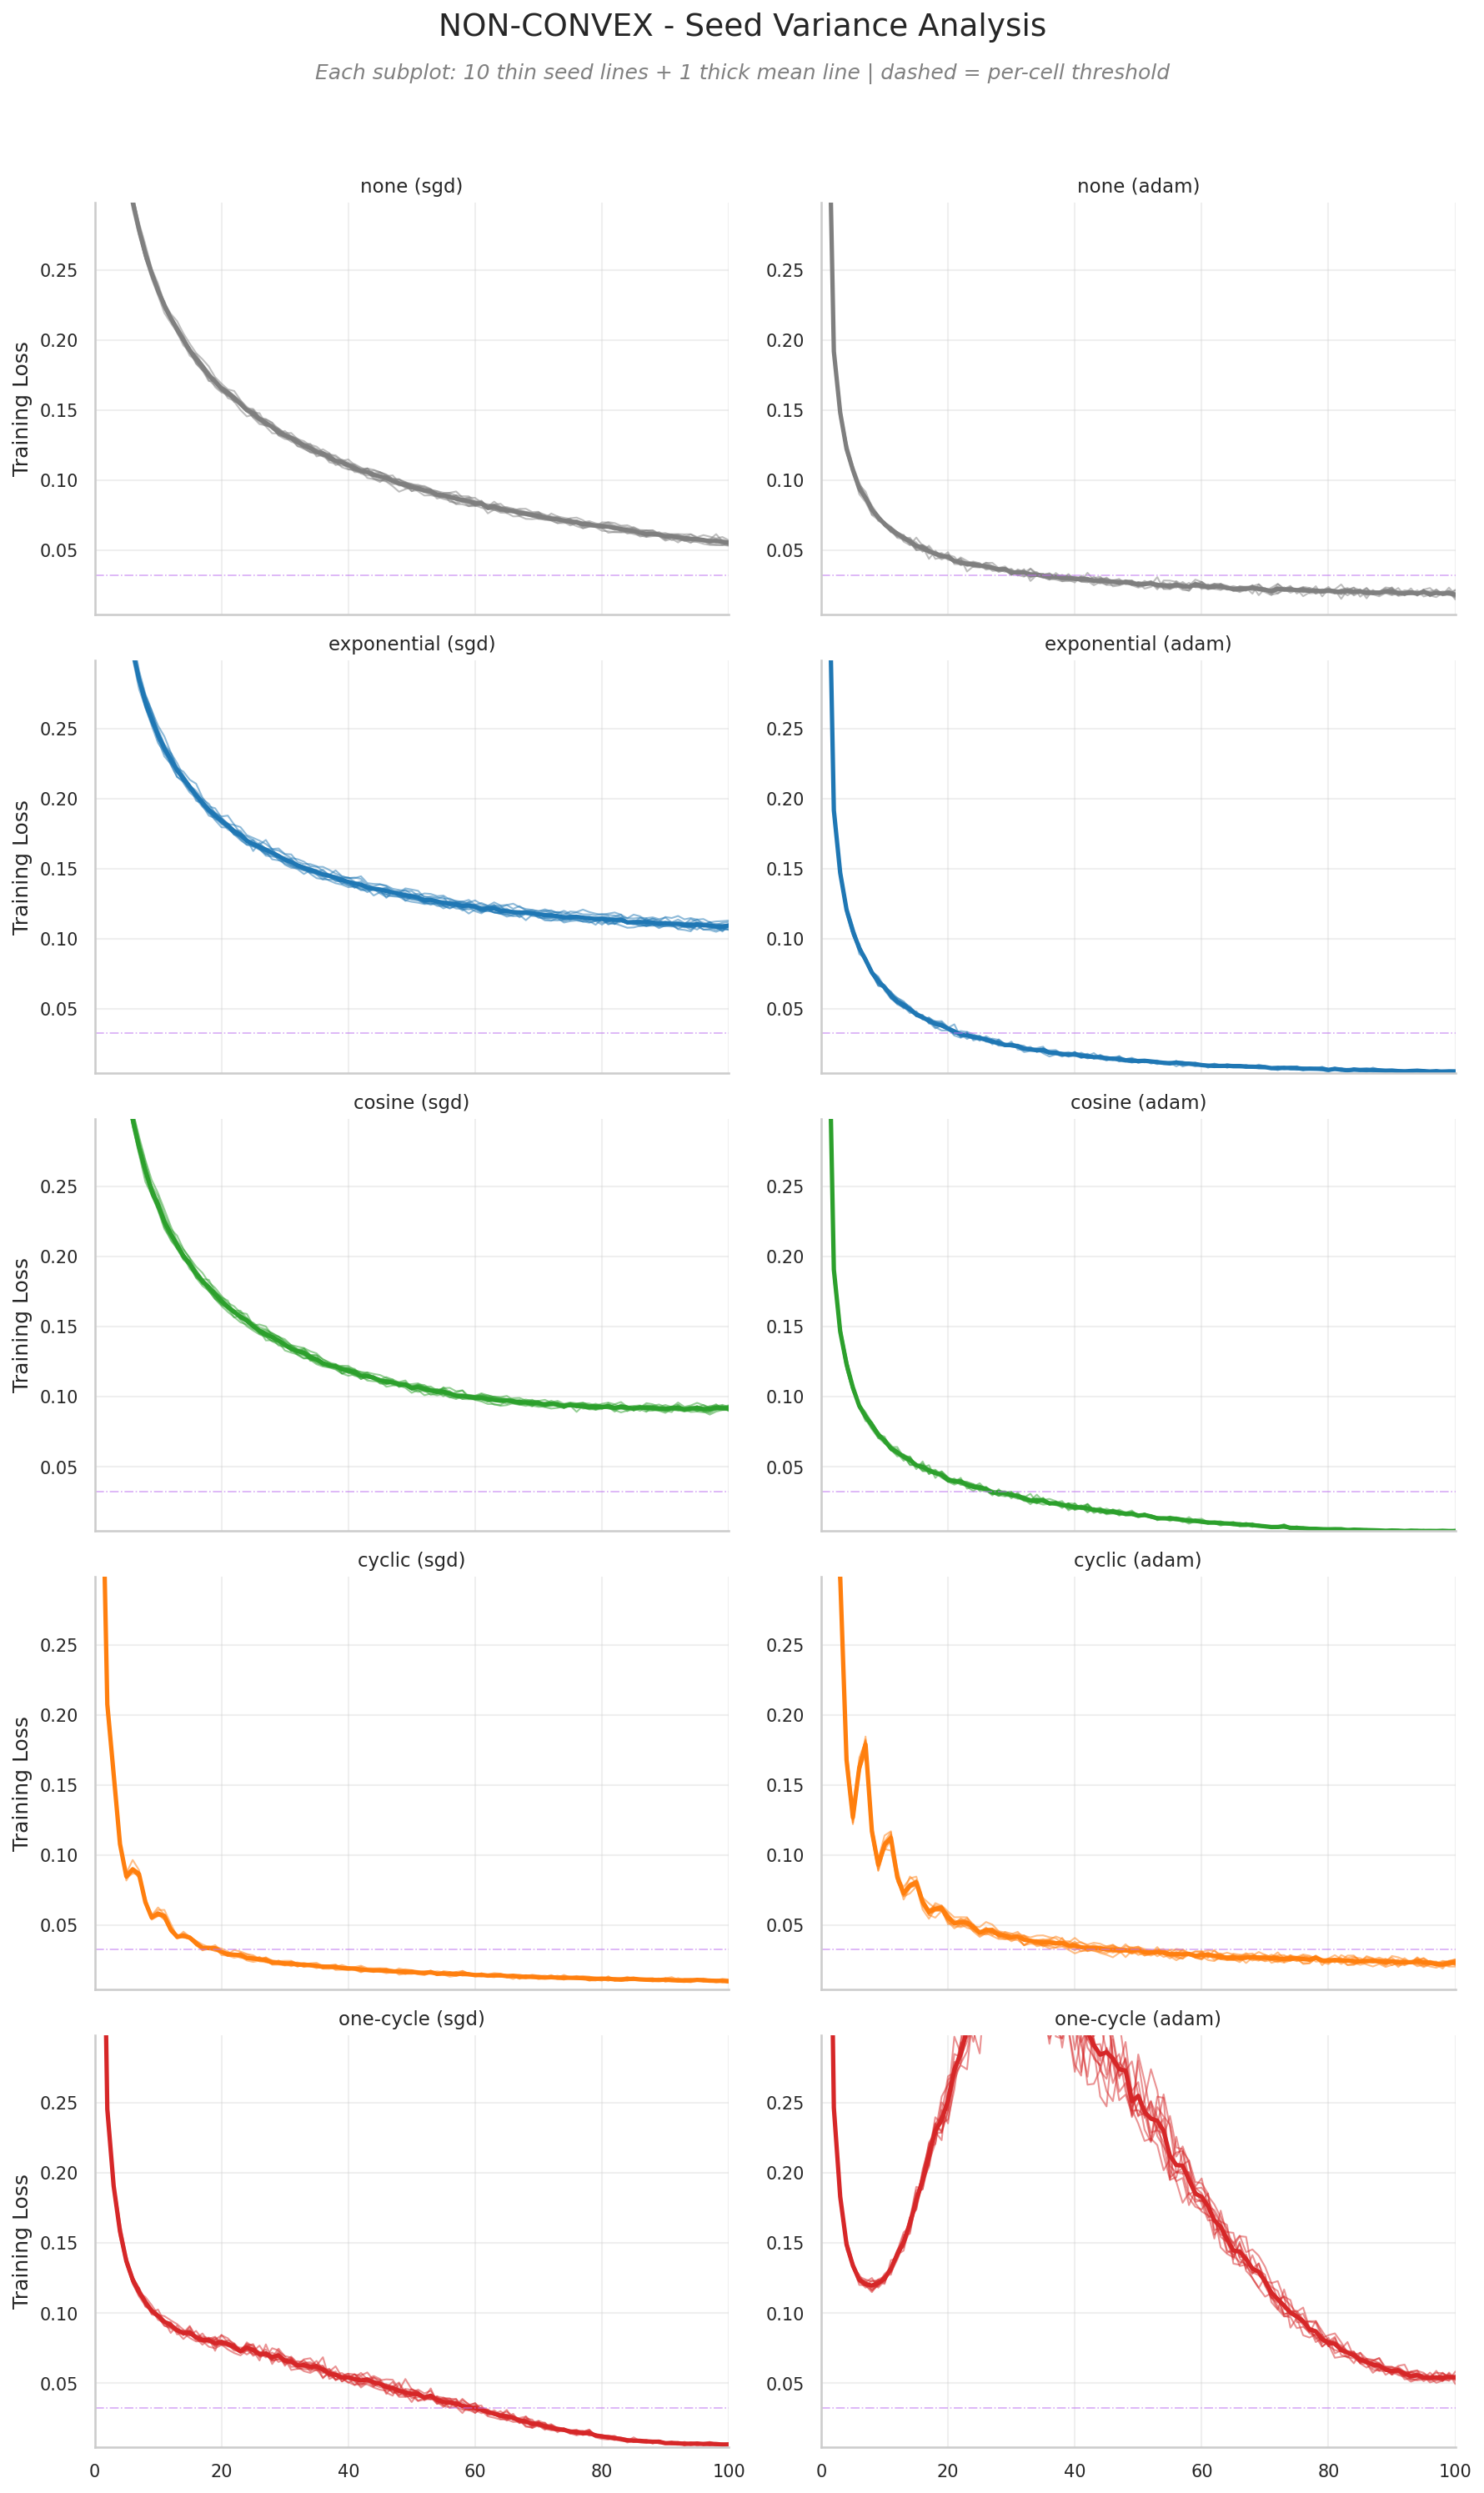

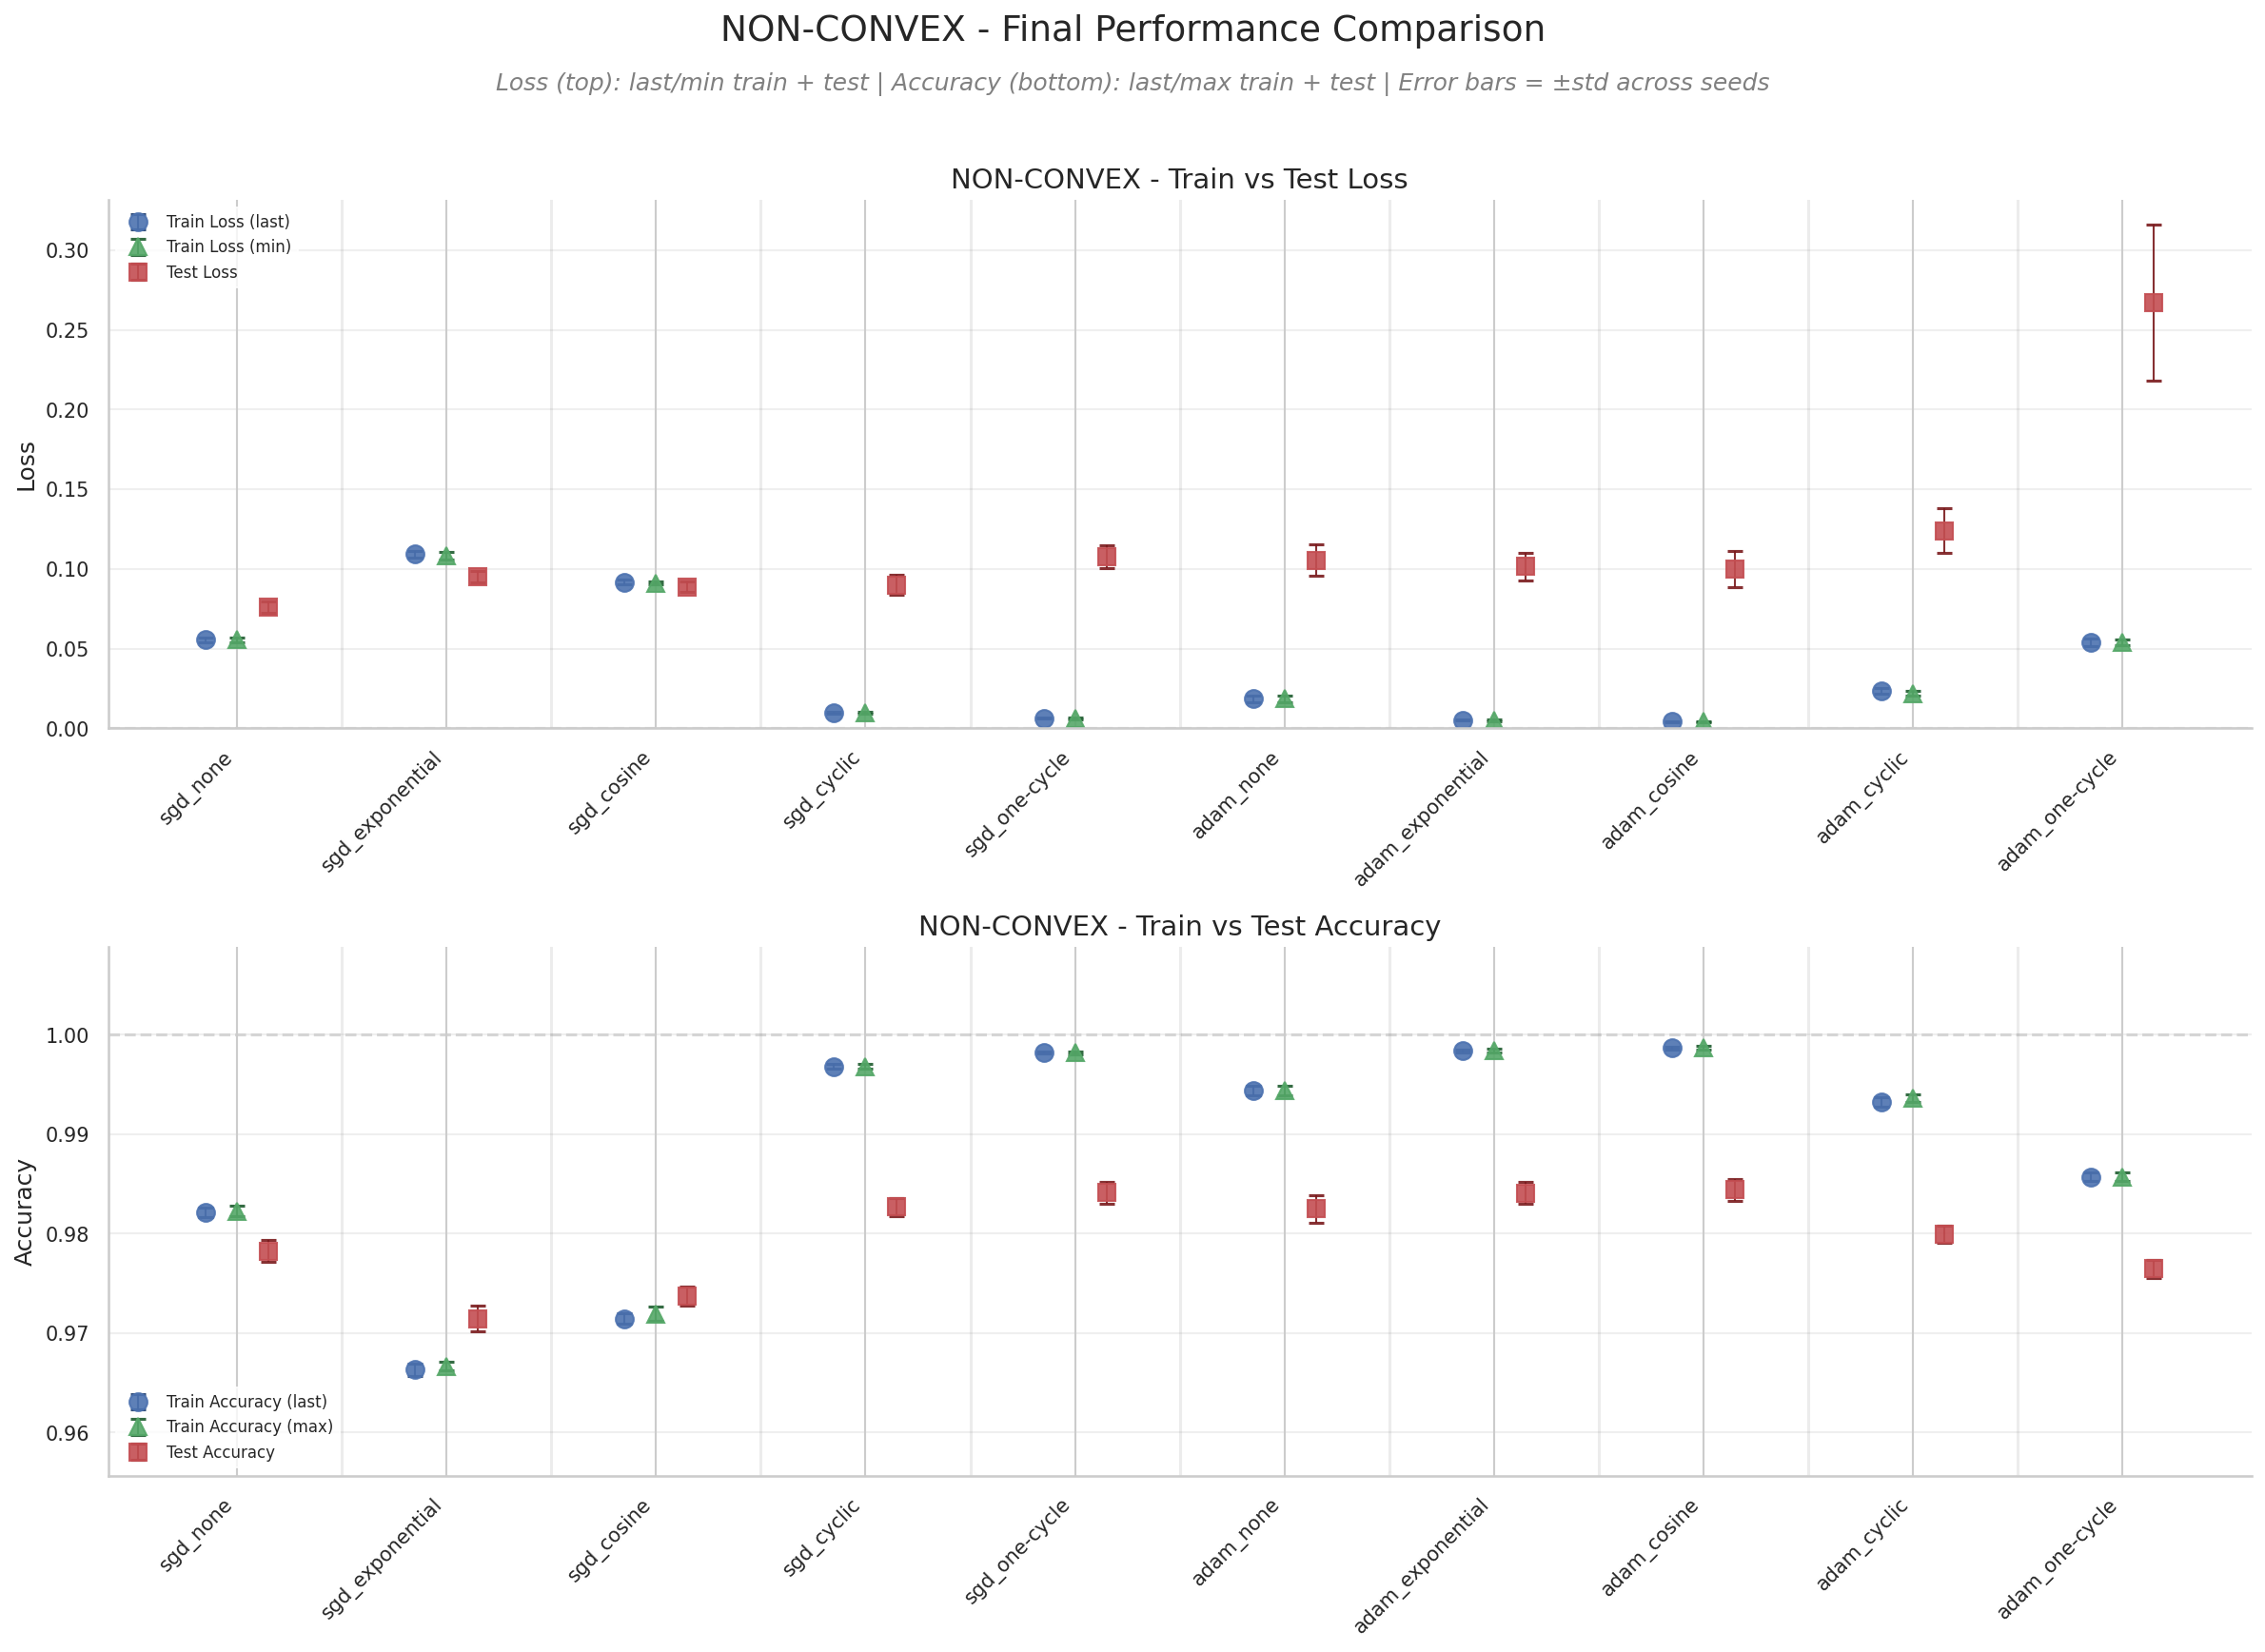

[viz] Saved: ../reports/figures/non-convex_analytical_a_loss_lr_dual.png


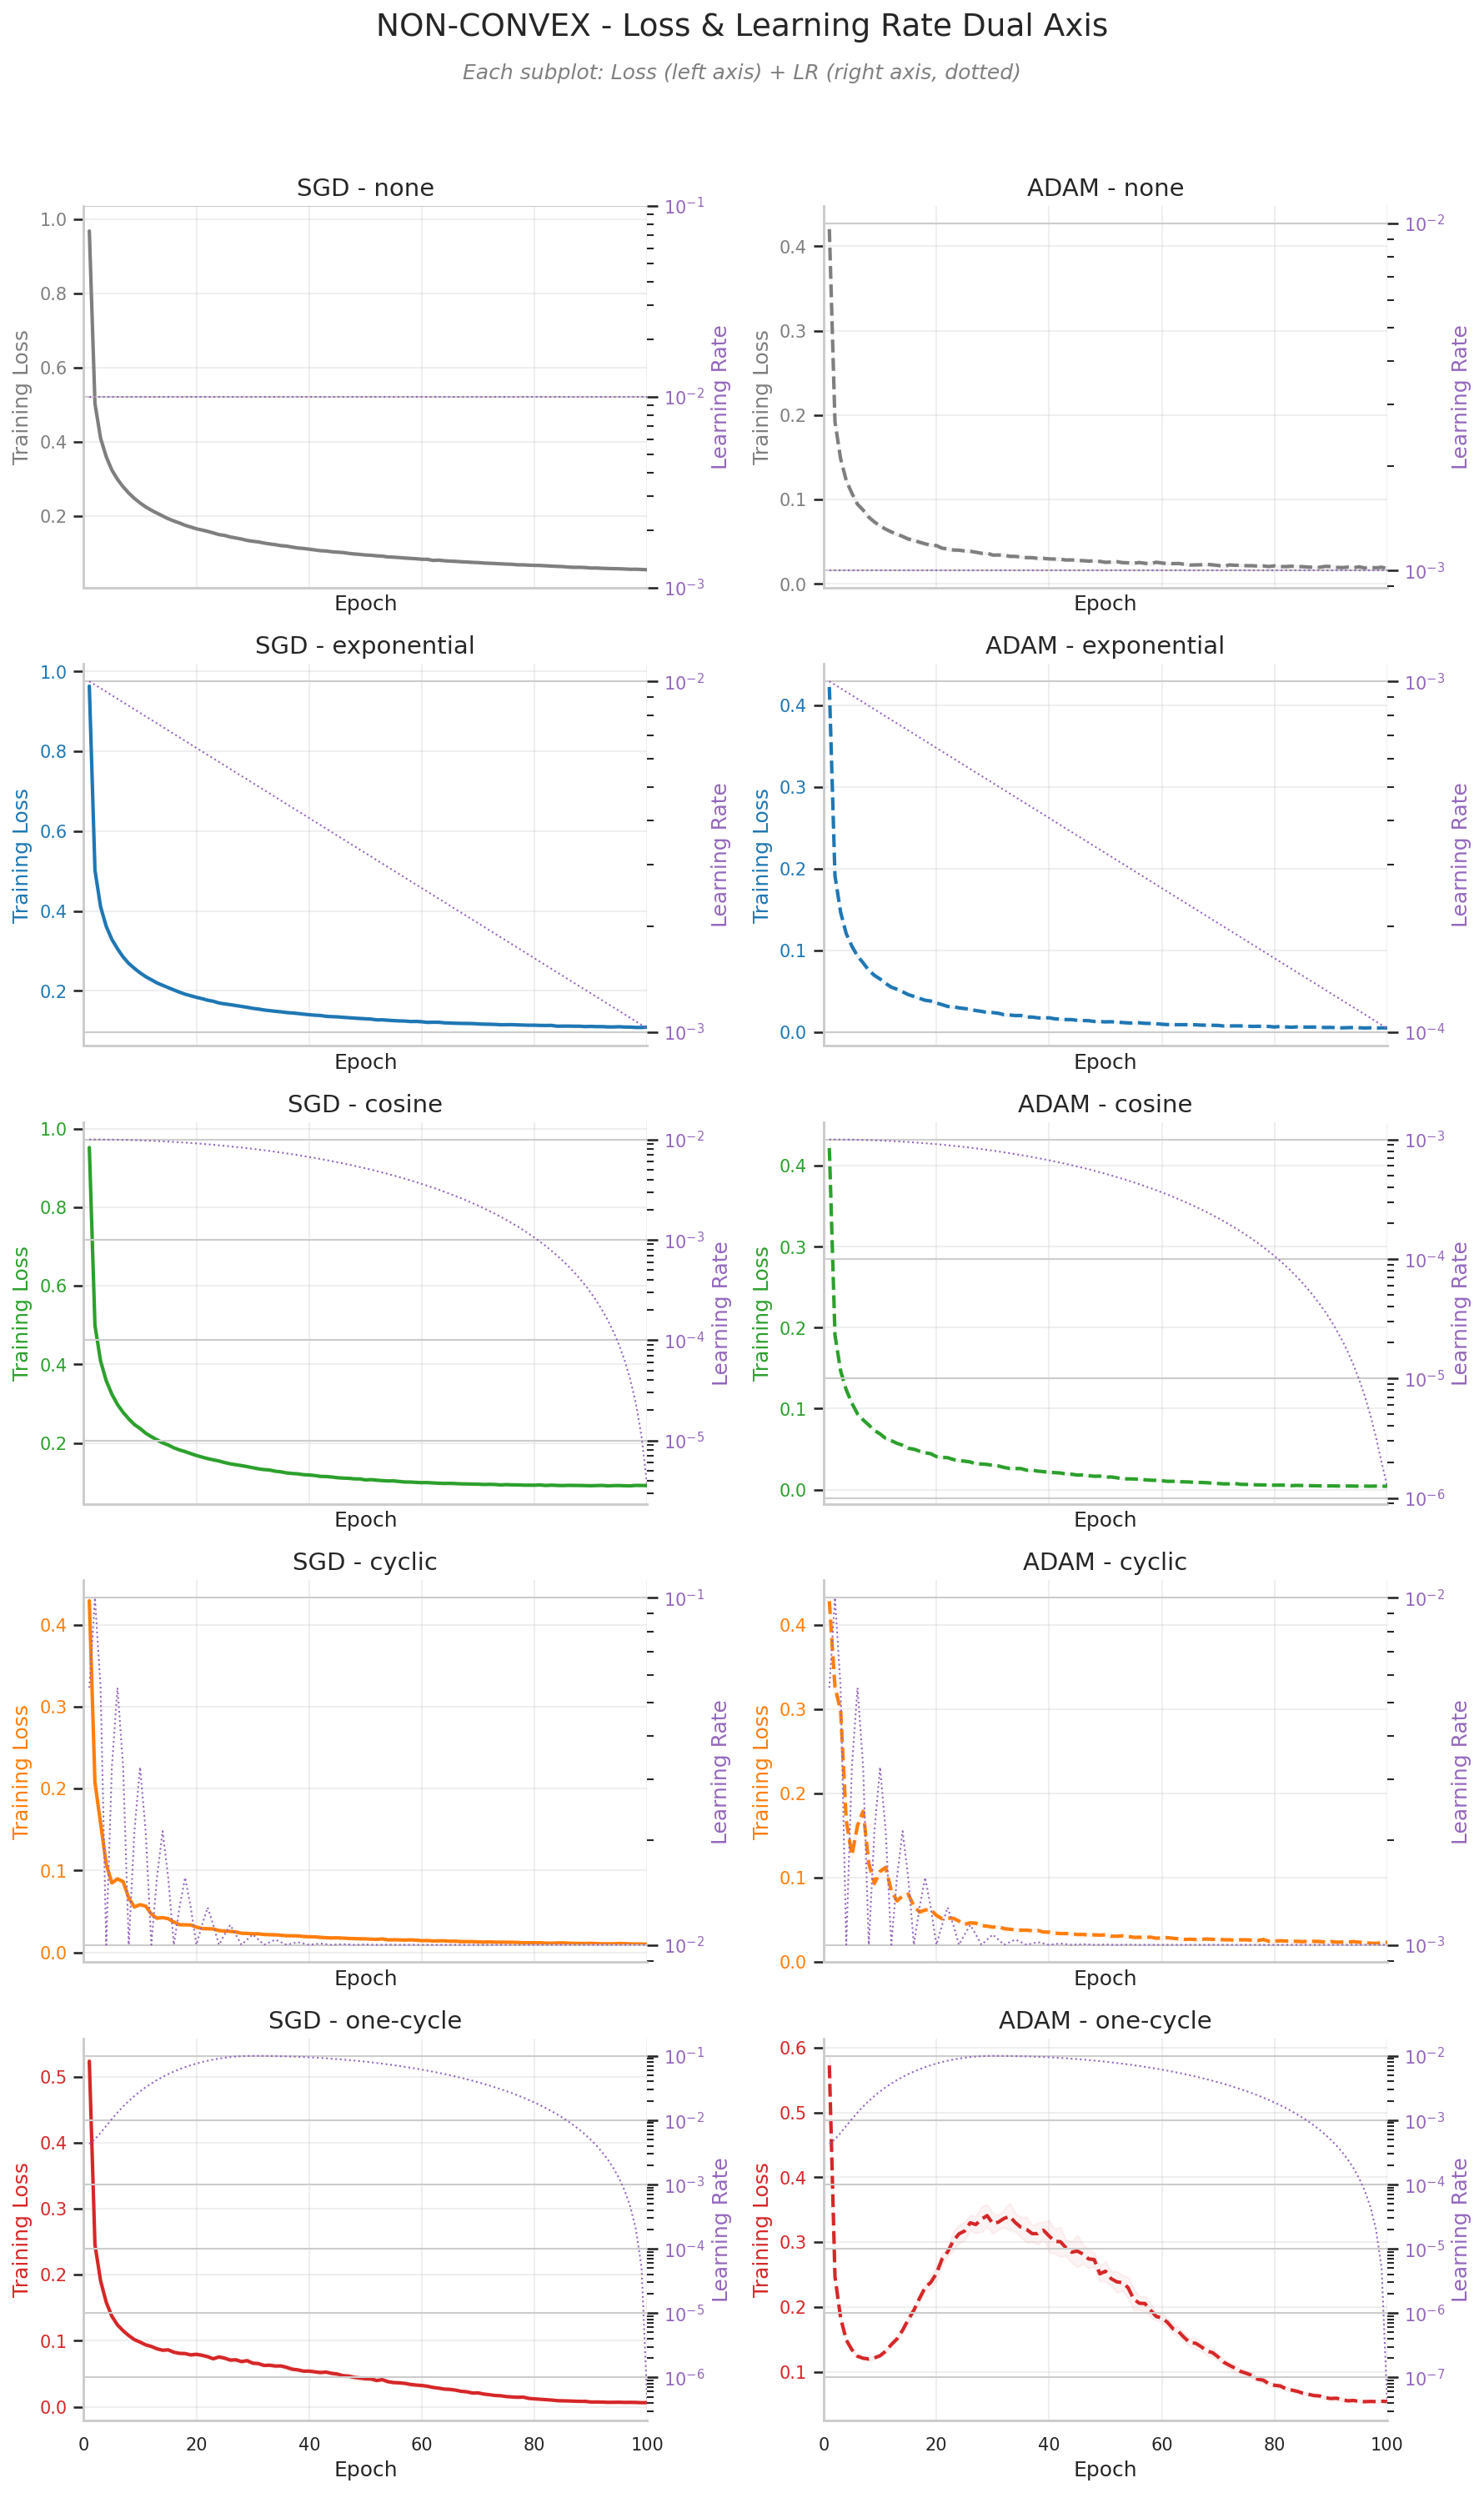

[viz] All plots saved for: non-convex


Saved 5 plot files:
  - ../reports/figures/non-convex_level1_global_comparison.png
  - ../reports/figures/non-convex_level2_by_optimizer.png
  - ../reports/figures/non-convex_level3_seed_variance.png
  - ../reports/figures/non-convex_level4_final_performance.png
  - ../reports/figures/non-convex_analytical_a_loss_lr_dual.png


In [16]:

# Generate all plots for both problem types
for problem_type in ["convex", "non-convex"]:
    print(f"\n{'='*60}")
    print(f"Generating plots for: {problem_type.upper()}")
    print('='*60)
    
    # Get aggregated metrics
    aggregated = convergence_results[problem_type]["aggregated"]
    
    # Get results for this problem type
    results_by_problem = results[problem_type]
    
    # Compute L_star if available (for convex problems)
    L_star_global = convergence_results[problem_type]["L_star"]
    L0_global = convergence_results[problem_type].get("L0")
    print(f"L_star = {L_star_global:.6f}, L0 = {L0_global:.6f}")

    
    # Generate all plots
    saved_files = plot_all(
        results_by_problem=results_by_problem,
        aggregated=aggregated,
        problem_type=problem_type,
        L_star_global=L_star_global,
        L0=L0_global,
        save_dir=figures_dir,
        show=True,  # Set to True to display plots
    )
    
    print(f"Saved {len(saved_files)} plot files:")
    for f in saved_files:
        print(f"  - {f}")

## 6b. Convergence Velocity (Epochs-to-Target Boxplots)

For each E_target level, visualize the distribution of epochs required
to reach the target loss across all configurations and seeds.


CONVEX - Convergence Boxplot (5% above L* target)


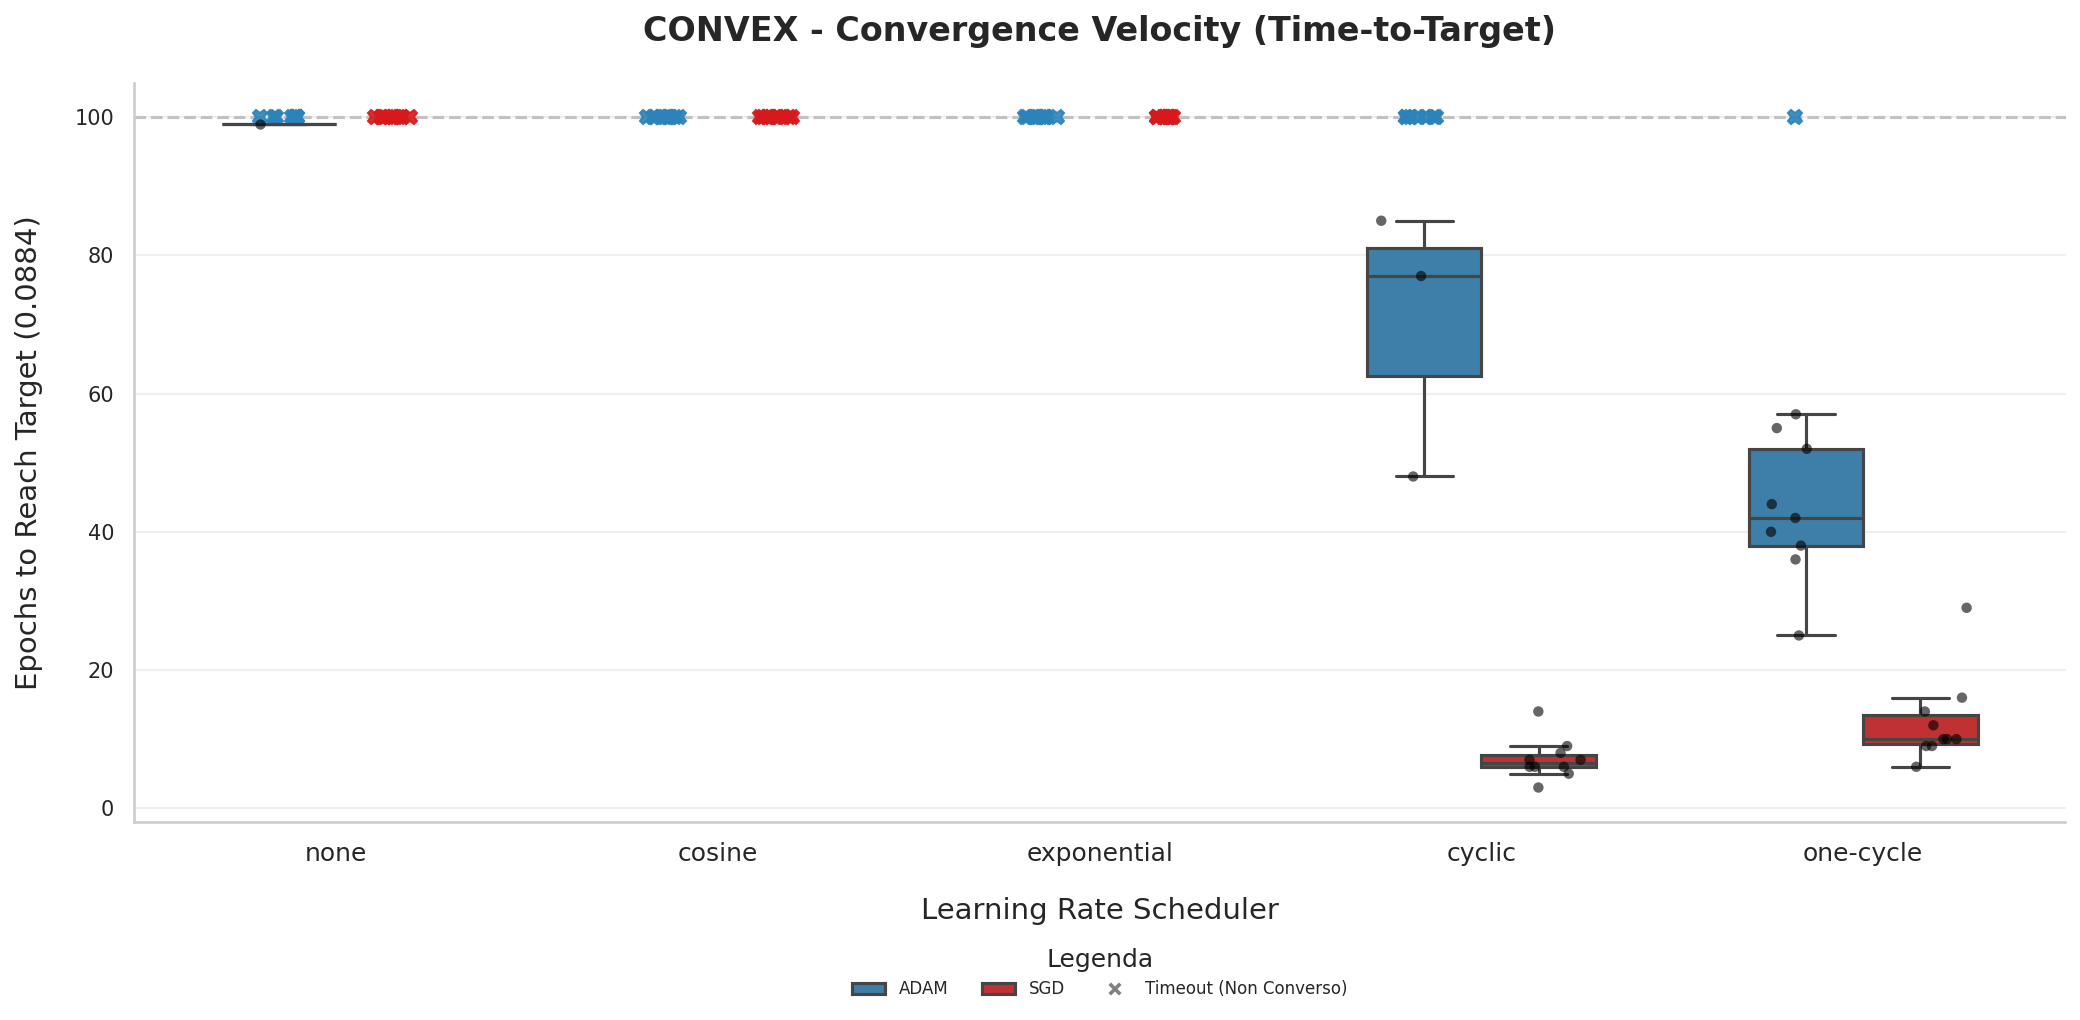


NON-CONVEX - Convergence Boxplot (5% above L* target)


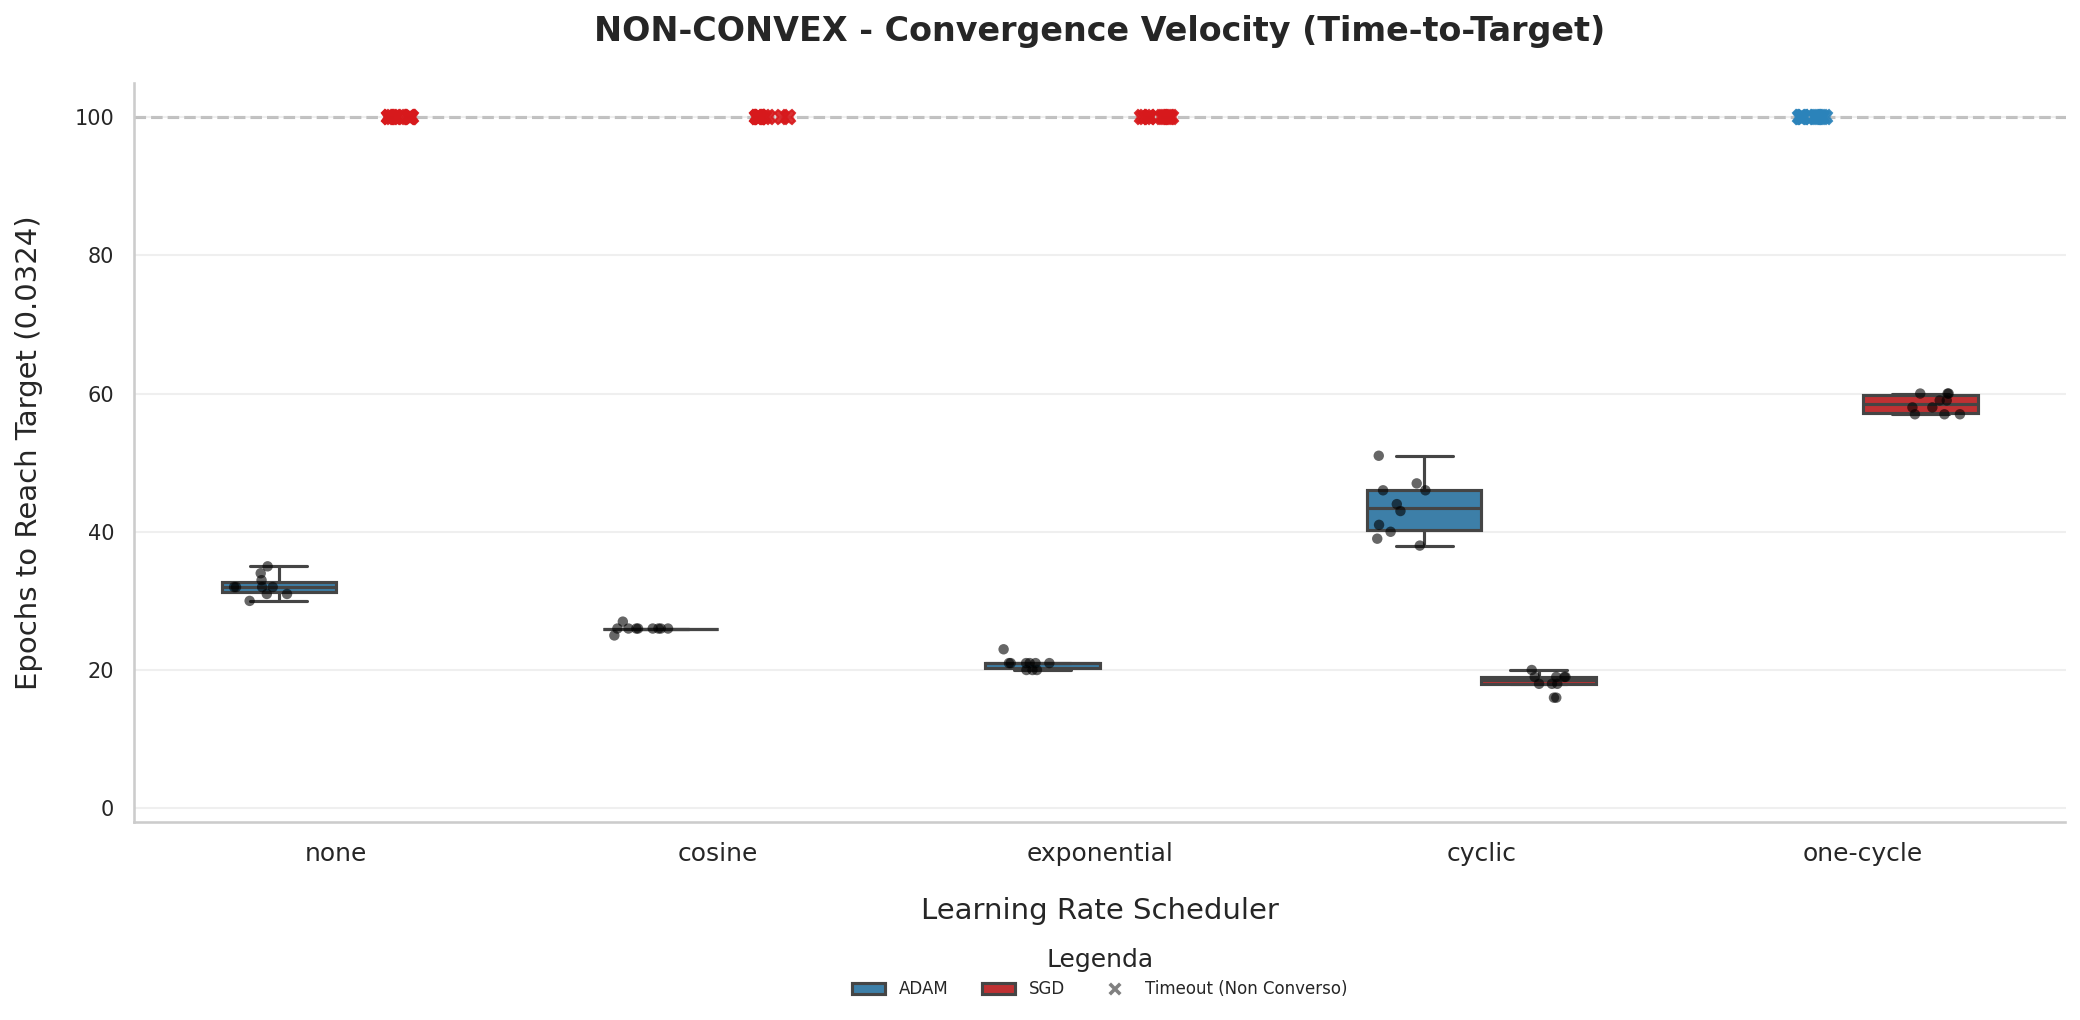

In [19]:
from stoc_opt_scheduler_comparison.visualization.plots import plot_convergence_boxplot

target_epsilon = 0.05  # 5% above L*

for problem_type in ["convex", "non-convex"]:
    print(f"\n{'='*60}")
    print(f"{problem_type.upper()} - Convergence Boxplot ({target_epsilon*100:.0f}% above L* target)")
    print(f"{'='*60}")

    # Get per-run metrics for this problem type
    metrics_dict = convergence_results[problem_type]["per_run"]

    # Get L_star and L0 for this problem type
    L_star = convergence_results[problem_type]["L_star"]
    L0 = convergence_results[problem_type].get("L0")
    max_epochs = convergence_results[problem_type]["max_epochs"]

    # Generate boxplot for epochs-to-target at the specified E_target level
    save_path = figures_dir / f"{problem_type}_convergence_boxplot_{target_epsilon*100:.0f}.png"
    plot_convergence_boxplot(
        data=metrics_dict,
        problem_type=problem_type,
        L_star=L_star,
        L0=L0,
        e_target_epsilon=target_epsilon,
        max_epochs=max_epochs,
        save_path=save_path,
        show=True
    )


## 6c. Heatmap of Convergence Metrics


Heatmap for: CONVEX


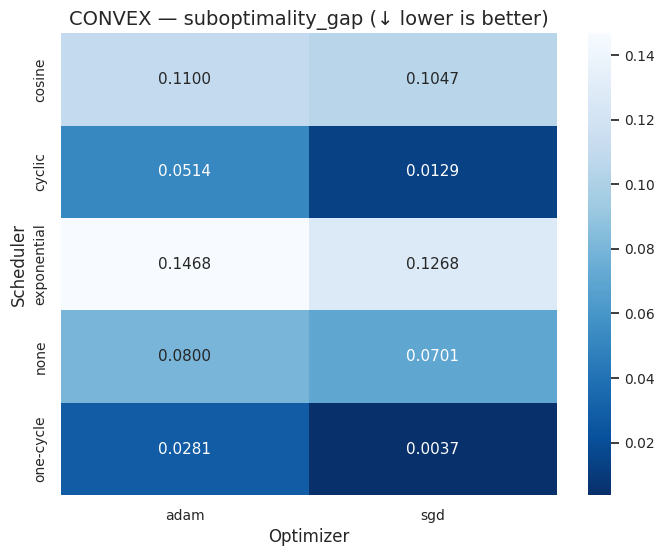

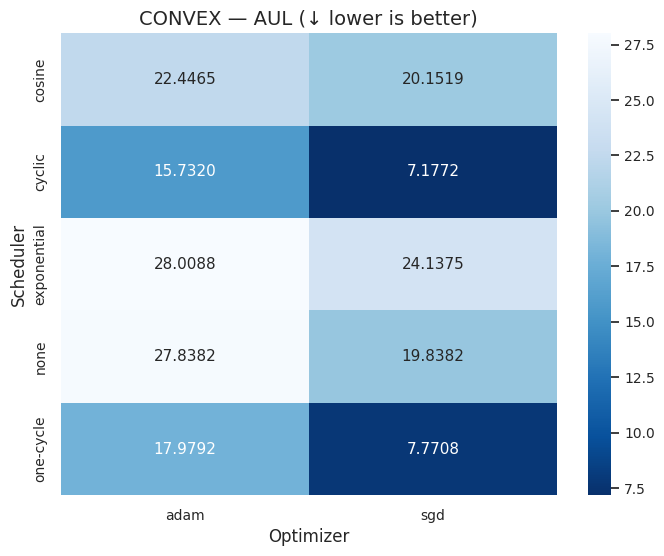

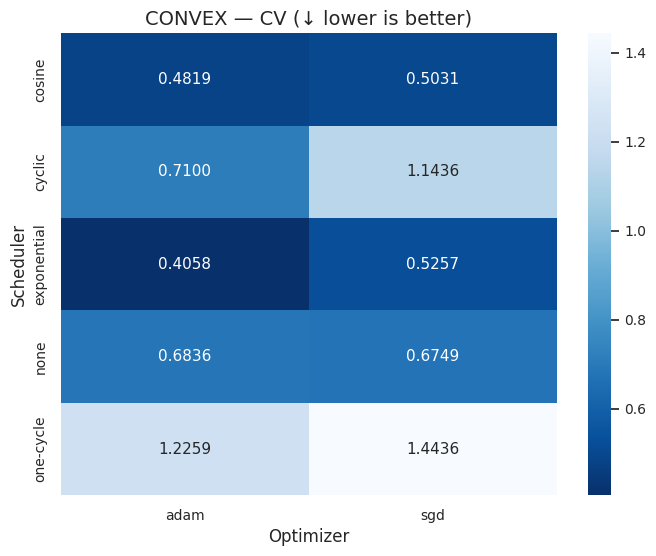

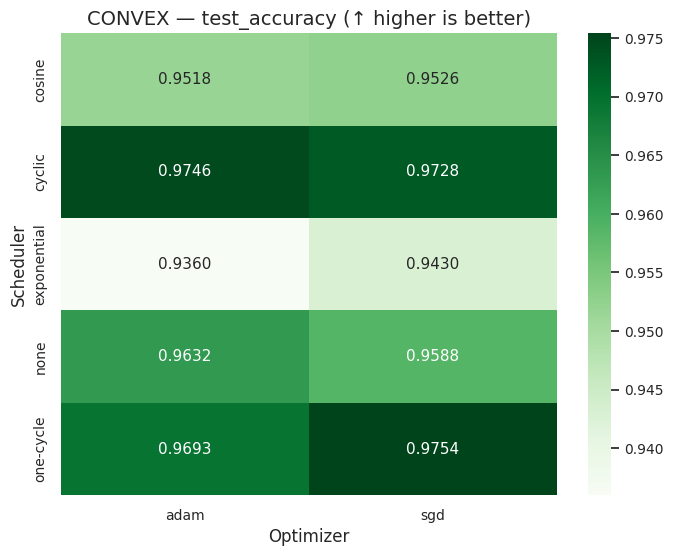


Heatmap for: NON-CONVEX


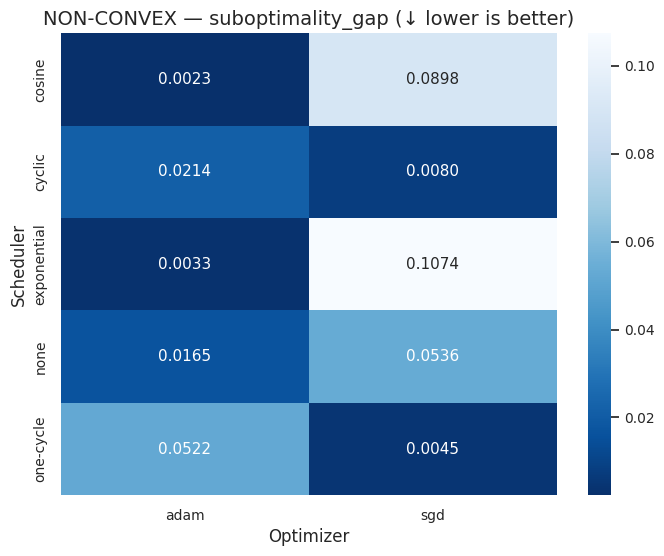

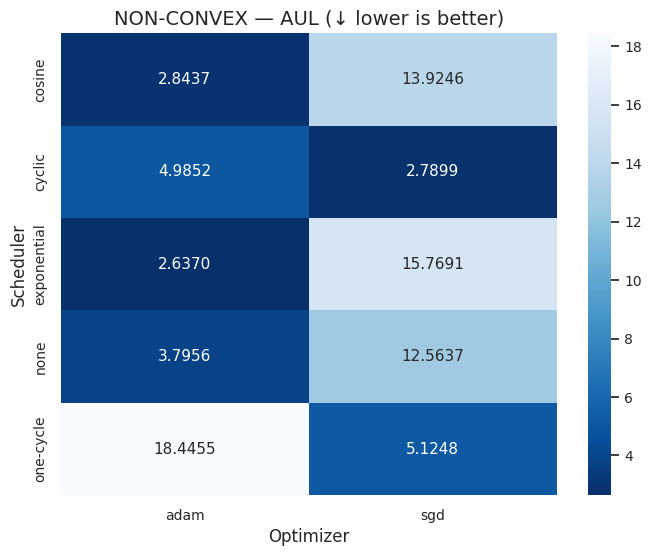

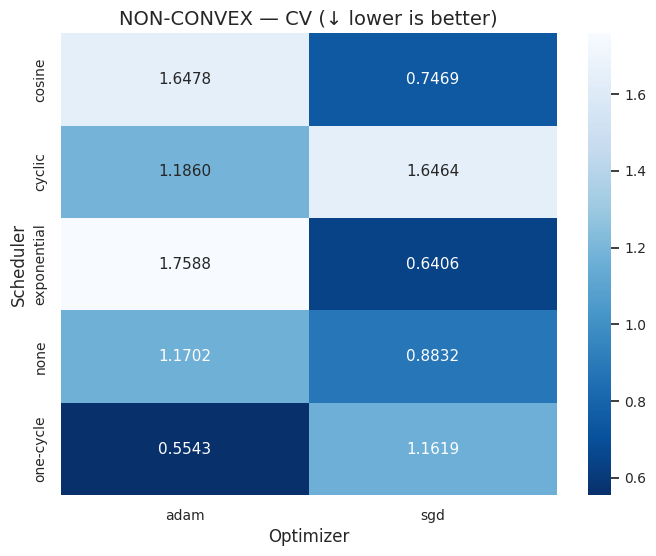

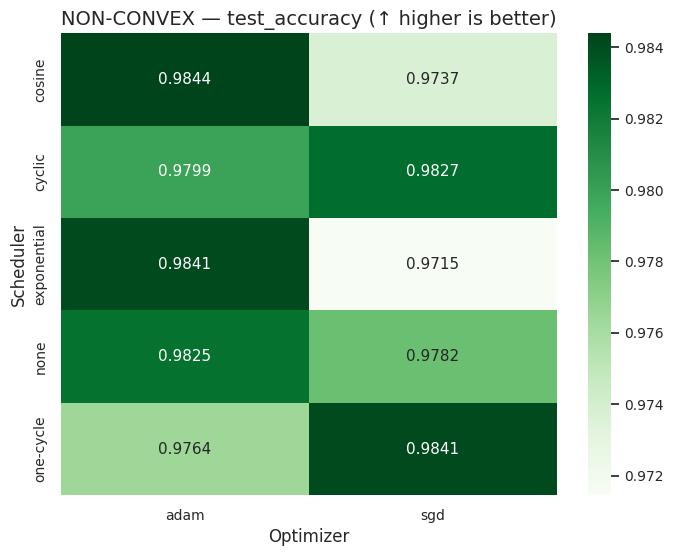

In [27]:
# Analytical B: Heatmap (returns list of saved files)
from stoc_opt_scheduler_comparison.visualization.plots import plot_scheduler_optimizer_heatmap

for problem_type in ["convex", "non-convex"]:

    print(f"\n{'='*60}")
    print(f"Heatmap for: {problem_type.upper()}")
    print('='*60)

    save_path = figures_dir / f"{problem_type}_analytical_b_heatmap.png"

    agg_met = convergence_results[problem_type]["aggregated"]


    plot_scheduler_optimizer_heatmap(
        agg_met, problem_type,
        metrics=["suboptimality_gap", "AUL", "CV", "test_accuracy"],
        save_path=save_path,
        show=True
    )

## 7. Summary & Key Findings

### Best Configuration per Problem Type

In [18]:
import math

for problem_type in ["convex", "non-convex"]:
    agg = convergence_results[problem_type]["aggregated"]
    
    # Find best by accuracy
    best_acc_key = max(agg.keys(), key=lambda k: agg[k].get("test_accuracy_mean", 0))
    best_acc = agg[best_acc_key]
    
    # Find fastest convergence (lowest EtT), ignoring NaNs
    best_ett_key = min(
        agg.keys(), 
        key=lambda k: float("inf") if math.isnan(agg[k].get("EtT_mean", float("inf"))) else agg[k].get("EtT_mean", float("inf"))
    )
    best_ett = agg[best_ett_key]
    
    # Find most stable (lowest CV), ignoring NaNs
    best_stable_key = min(
        agg.keys(),
        key=lambda k: float("inf") if math.isnan(agg[k].get("CV_mean", float("inf"))) else agg[k].get("CV_mean", float("inf"))
    )
    best_stable = agg[best_stable_key]
    
    # Find best AUL (lowest Area Under Loss), ignoring NaNs
    best_aul_key = min(
        agg.keys(),
        key=lambda k: float("inf") if math.isnan(agg[k].get("AUL_mean", float("inf"))) else agg[k].get("AUL_mean", float("inf"))
    )
    best_aul = agg[best_aul_key]
    
    # Find best suboptimality gap (lowest suboptimality), ignoring NaNs
    best_subopt_key = min(
        agg.keys(),
        key=lambda k: float("inf") if math.isnan(agg[k].get("suboptimality_gap_mean", float("inf"))) else agg[k].get("suboptimality_gap_mean", float("inf"))
    )
    best_subopt = agg[best_subopt_key]
    
    print(f"\n{'='*65}")
    print(f"{problem_type.upper()} - Summary")
    print(f"{'='*65}")
    print(f"Best accuracy:     {best_acc['optimizer']} + {best_acc['scheduler']} → {best_acc['test_accuracy_mean']*100:.2f}% ± {best_acc['test_accuracy_std']*100:.2f}")
    print(f"Fastest converge:  {best_ett['optimizer']} + {best_ett['scheduler']} → EtT = {best_ett['EtT_mean']:.1f} ± {best_ett['EtT_std']:.1f}")
    print(f"Most stable:       {best_stable['optimizer']} + {best_stable['scheduler']} → CV = {best_stable['CV_mean']:.4f} ± {best_stable['CV_std']:.4f}")
    print(f"Best AUL:          {best_aul['optimizer']} + {best_aul['scheduler']} → AUL = {best_aul['AUL_mean']:.4f} ± {best_aul['AUL_std']:.4f}")
    print(f"Best subopt. gap:  {best_subopt['optimizer']} + {best_subopt['scheduler']} → Gap = {best_subopt['suboptimality_gap_mean']:.6f} ± {best_subopt['suboptimality_gap_std']:.6f}")


CONVEX - Summary
Best accuracy:     sgd + one-cycle → 97.54% ± 0.94
Fastest converge:  sgd + cyclic → EtT = 7.1 ± 2.8
Most stable:       adam + exponential → CV = 0.4058 ± 0.0747
Best AUL:          sgd + cyclic → AUL = 7.1772 ± 0.9076
Best subopt. gap:  sgd + one-cycle → Gap = 0.004100 ± 0.009021

NON-CONVEX - Summary
Best accuracy:     adam + cosine → 98.44% ± 0.11
Fastest converge:  sgd + cyclic → EtT = 18.2 ± 1.2
Most stable:       adam + one-cycle → CV = 0.5543 ± 0.0055
Best AUL:          adam + exponential → AUL = 2.6370 ± 0.0375
Best subopt. gap:  adam + cosine → Gap = 0.002208 ± 0.000424


In [ ]:
convergence_results["convex"]["aggregated"][best_acc_key].keys()
#dict_keys(['optimizer', 'scheduler', 'AUL_mean', 'AUL_std', 'suboptimality_gap_mean', 'suboptimality_gap_std', 'CV_mean', 'CV_std', 'test_loss_mean', 'test_loss_std', 'test_accuracy_mean', 'test_accuracy_std', 'EtT_convergence_rate', 'EtT_mean', 'EtT_std'])

dict_keys(['optimizer', 'scheduler', 'n_runs', 'AUL_mean', 'AUL_std', 'suboptimality_gap_mean', 'suboptimality_gap_std', 'CV_mean', 'CV_std', 'test_loss_mean', 'test_loss_std', 'test_accuracy_mean', 'test_accuracy_std', 'EtT_convergence_rate', 'EtT_mean', 'EtT_std', 'EtT_median', 'train_losses_mean', 'train_losses_std', 'train_accuracies_mean', 'train_accuracies_std', 'learning_rates_mean', 'learning_rates_std'])

In [38]:
import json
import math
from pathlib import Path

# 1. Definisci le chiavi da estrarre
keys_to_keep = [
    'optimizer', 'scheduler', 'AUL_mean', 'AUL_std', 
    'suboptimality_gap_mean', 'suboptimality_gap_std', 
    'CV_mean', 'CV_std', 'test_loss_mean', 'test_loss_std', 
    'test_accuracy_mean', 'test_accuracy_std', 
    'EtT_convergence_rate', 'EtT_mean', 'EtT_std'
]

# Helper function per convertire i NaN float nel None di Python (che diventa null in JSON)
def clean_value(val):
    if isinstance(val, float) and math.isnan(val):
        return None
    return val

# 2. Crea la struttura dati filtrata e bonificata
filtered_results = {}

for problem_type, problem_data in convergence_results.items():
    filtered_results[problem_type] = {}
    aggregated_runs = problem_data.get("aggregated", {})
    
    for run_id, run_data in aggregated_runs.items():
        # Estrai e bonifica i valori uno a uno
        filtered_results[problem_type][run_id] = {
            k: clean_value(run_data[k]) for k in keys_to_keep if k in run_data
        }

# 3. Salva il file in formato JSON standard e valido
output_path = Path("../results/summary_metrics.json")
output_path.parent.mkdir(parents=True, exist_ok=True)

with open(output_path, "w", encoding="utf-8") as f:
    # allow_nan=False garantisce che se sfugge qualcosa il codice si ferma invece di generare un file corrotto
    json.dump(filtered_results, f, indent=4, ensure_ascii=False, allow_nan=False)

print(f"Dati validati e salvati correttamente in: {output_path}")

Dati validati e salvati correttamente in: ../results/summary_metrics.json


## 8. Save and Load Results

### Save Convergence metrics

In [ ]:
# Export results to CSV for further analysis
for problem_type in ["convex", "non-convex"]:
    metrics_list = convergence_results[problem_type]["per_run"]
    df = pd.DataFrame(metrics_list)
    csv_path = results_dir / f"{problem_type}_metrics.csv"
    df.to_csv(csv_path, index=False)
    print(f"Saved: {csv_path} ({len(df)} rows)")        

Saved: ../results/convex_metrics.csv (19 rows)
Saved: ../results/non-convex_metrics.csv (19 rows)


### Save results dict

In [52]:
def save_results(results: dict, save_dir: str | Path = Path("../results"), filename: str = "results.pkl") -> Path:
    """
    Serialize results dict to disk using pickle (no compression, no conversion).

    Args:
        results:  The dict to save.
        save_dir: Directory where the file will be written (created if missing).
        filename: Output filename (default: results.pkl).

    Returns:
        Path of the saved file.
    """
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    output_path = save_dir / filename
    with open(output_path, "wb") as f:
        pickle.dump(results, f, protocol=pickle.HIGHEST_PROTOCOL)
    return output_path

# Salvataggio
save_results(results, save_dir=results_dir, filename="results_v5.pkl")


PosixPath('../results/results_v5.pkl')

### Load results dict

In [5]:
def load_results(save_dir: str | Path = Path("../results"), filename: str = "results.pkl") -> dict:
    """
    Load results dict from disk.

    Args:
        save_dir: Directory containing the file.
        filename: File to load (default: results.pkl).

    Returns:
        The deserialized dict.

    Raises:
        FileNotFoundError: If the file does not exist.
    """
    path = Path(save_dir) / filename
    if not path.exists():
        raise FileNotFoundError(f"Results file not found: {path}")
    with open(path, "rb") as f:
        return pickle.load(f)
    

# Caricamento
results = load_results(save_dir=results_dir, filename="results_v5.pkl")

## Load Result from MlFLow

In [6]:
results = load_results_from_mlflow(
    experiment_name="scheduler_comparison_v3",
    tracking_uri="../mlruns",  # o URI remoto
)

/home/narto/Documents/uni_projects/MOS/stoc-opt_scheduler_comparison/.venv/lib/python3.10/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
